# Contextual Rule Analysis

This notebook develops and evaluates contextual classification rules for buildings that cannot be resolved directly from explicit OpenStreetMap tags. Stage 1 classifications are used as reference labels to assess candidate rules based on building area, address information, neighboring buildings, and spatial context.

**Input**
- Building data with Stage 1 direct-tag classifications.
- Basic geometric and address features used to construct contextual rules.

**Output**
- Evaluated candidate rules and their classification precision.
- Selected high-confidence contextual rules for implementation in Stage 2.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys



ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

INPUT_FILE = os.path.join(DATA_DIR, 'processed', 'germany_buildings_classified_stage1.parquet')
LANDUSE_FILE = os.path.join(DATA_DIR, 'interim', 'germany_landuse.parquet')
POI_FILE = os.path.join(DATA_DIR, 'interim', 'germany_poi.parquet')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)


In [2]:
print("Loading Germany Data...")

# 1. Load Parquet files
gdf_bldg = gpd.read_parquet(INPUT_FILE)

print("Data loaded successfully!")

Loading Germany Data...
Data loaded successfully!


In [3]:
gdf_bldg.columns

Index(['id', 'geometry', 'building', 'tag_l1', 'tag_l2', 'is_abandoned',
       'tag_is_mixed', 'tag_source', 'tag_used', 'all_candidates', 'addr:city',
       'addr:housenumber', 'addr:postcode', 'addr:street', 'name', 'amenity',
       'building:use', 'craft', 'office', 'shop', 'tags', 'building:levels',
       'address_tier', 'area_sqm', 'perimeter_m', 'compactness', 'building_l1',
       'building_l2', 'building_is_mixed', 'buse_l1', 'buse_l2',
       'buse_is_mixed', 'amenity_l1', 'amenity_l2', 'shop_l1', 'shop_l2',
       'stage1_l1', 'stage1_l2', 'stage1_is_mixed', 'stage1_source',
       'raw_label'],
      dtype='object')

### Address Distribution

In [4]:
# Cross-tab: address tier vs type (within this ambiguous band only)
print(pd.crosstab(
    gdf_bldg['address_tier'], 
    gdf_bldg['stage1_l1'],
    normalize='columns'
).round(3) * 100)


stage1_l1     agricultural  civic  commercial  filter  industrial  military  \
address_tier                                                                  
0                     96.1   42.5        38.9    98.5        76.0      91.8   
1                      1.5    6.9         5.7     0.8         2.9       1.6   
2                      2.4   50.6        55.4     0.8        21.0       6.5   

stage1_l1     residential  semi_commercial  transportation  
address_tier                                                
0                    16.9              3.9            74.2  
1                     7.3              0.2             4.6  
2                    75.8             95.9            21.2  


agricultural, military and filter buildings genereally do not have addresses- while most residential buildings have addresses

### Area Distribution Analysis

In [5]:
# area distribution by category

gdf_bldg.groupby('stage1_l1')['area_sqm'].describe()


,count,mean,std,min,25%,50%,75%,max
stage1_l1,,,,,,,,
agricultural,313609.0,446.940926,1737.312305,0.351607,94.648969,209.820182,461.703714,480319.437593
civic,311495.0,679.649442,1017.173408,0.135825,190.685784,399.667198,800.442404,134660.094887
commercial,424475.0,799.284117,1873.644704,0.785768,147.671317,338.551490,822.306988,145646.842085
filter,4121244.0,49.475217,129.086617,0.007064,18.555114,30.213194,49.444604,52278.633578
industrial,301728.0,1377.757071,4318.344465,0.132428,63.431857,333.611604,1010.969878,218354.425848
military,8288.0,491.384023,826.919042,0.387245,141.764671,289.796095,624.524354,35606.465760
residential,7765260.0,150.761727,139.148036,0.007160,83.470614,122.770958,176.579722,47762.209061
semi_commercial,3692.0,225.546204,286.779516,7.444443,106.590840,154.924847,241.378878,6307.119436
transportation,22301.0,986.562275,2213.583820,0.219911,86.038750,358.889941,1092.082270,76100.253733


mean here appears to be distorted by huge outliers, so median should be more reliable

- filter → 30 m² (garages, sheds, walls, etc., very tight and small)
- residential → 123 m² (very tight, low std of 139 — most consistent type)
- semi_commercial → 158 m² (close to residential, makes sense)
- agricultural → 211 m² (std > 1k)
- industrial → 281 m² (but enormous spread- std of 4099 means area alone won't classify industrial well)
commercial → 338 m² (std > 1k)
civic → 396 m² (std > 1k)

Things that stand out:
1. Filter has a max of 52,278 which is very huge. Need to check what is in the max outliers
2. Industrial has a p25 of only 57 m², meaning 25% of industrial buildings are tiny, even smaller than the median residential building. Need to check that too. 

In [6]:
# check what's actually in the filter max outliers
filter_bldgs = gdf_bldg[gdf_bldg['stage1_l1'] == 'filter']
filter_bldgs.nlargest(20, 'area_sqm')[['id', 'building','raw_label', 'area_sqm', 'stage1_l1', 'stage1_l2']]

,id,building,raw_label,area_sqm,stage1_l1,stage1_l2
38544330,1466430943,roof,roof,52278.633578,filter,None
38544331,1466430944,roof,roof,37453.619741,filter,None
26282034,547446581,no,no,35558.993608,filter,None
26108,25001469,roof,roof,33649.793698,filter,None
5263245,154801346,roof,roof,28460.491658,filter,None
12621762,261779426,roof,roof,27720.808023,filter,None
36357231,1205434132,no,no,26664.934720,filter,None
5337619,156255337,yes,loading_ramp,24669.611388,filter,None
29574037,747444766,ruins,ruins,22282.269782,filter,None
27560238,622338720,roof,roof,21526.870898,filter,None


filter outliers are actually fine. The roof tag in OSM means a canopy or shelter structure, not a building roof, so no action needed 

In [ ]:
# check what's in the industrial min outliers
industrial_bldgs = gdf_bldg[gdf_bldg['stage1_l1'] == 'industrial']
industrial_bldgs.nsmallest(20, 'area_sqm')[['id', 'building','raw_label', 'area_sqm', 'stage1_l1', 'stage1_l2']]

,id,building,raw_label,area_sqm,stage1_l1,stage1_l2
22213244,405492175,industrial,industrial,0.132428,industrial,None
21753058,395649221,yes,substation,0.304145,industrial,utilities
36994083,1282968914,service,transformer,0.358342,industrial,utilities
27391111,609308133,yes,substation,0.380275,industrial,utilities
15244416,296919834,warehouse,warehouse,0.448959,industrial,storage
19861978,360081070,industrial,industrial,0.475208,industrial,None
33256604,992581456,yes,transmission,0.600305,industrial,utilities
28695275,686100198,service,distribution,0.600742,industrial,utilities
38083152,1420759715,service,minor_distribution,0.607991,industrial,utilities
29283488,725375462,industrial,industrial,0.662854,industrial,None


they all fall into energy production or storage which looks okay also. We wont jut be able to create small area rules to assign industrial building types

In [8]:
# Get the building(s) with top 10 maximum area
top_20_max_area = gdf_bldg['area_sqm'].nlargest(20)
max_area_buildings = gdf_bldg[gdf_bldg['area_sqm'].isin(top_20_max_area)]

print(f"Top 20 maximum areas: {top_20_max_area.tolist()}")
print(f"\nBuilding(s) with top 20 maximum area:")
max_area_buildings[['id', 'building','raw_label', 'area_sqm', 'stage1_l1', 'stage1_l2']]

Top 20 maximum areas: [480319.437592945, 218354.42584763336, 203819.21144746375, 201391.74736894286, 188138.30372144378, 185586.79793252065, 179556.73277502405, 174486.20433086433, 171521.59311489723, 158548.2671479379, 157017.93632166635, 156380.1668450737, 156307.3161187106, 153825.13492573268, 152427.49907118143, 149087.78722433563, 149020.95758184625, 147769.52063598466, 145646.84208472498, 143627.97164697983]

Building(s) with top 20 maximum area:


,id,building,raw_label,area_sqm,stage1_l1,stage1_l2
340738,39207459,industrial,industrial,201391.747369,industrial,None
420599,42491578,industrial,industrial,185586.797933,industrial,None
608893,48166055,industrial,industrial,203819.211447,industrial,None
1224566,76918032,industrial,factory,188138.303721,industrial,manufacturing
1319598,82551759,industrial,industrial,147769.520636,industrial,None
2825196,110357622,industrial,works,156307.316119,industrial,manufacturing
3069209,115012891,yes,works,153825.134926,industrial,manufacturing
3765349,126838342,industrial,industrial,171521.593115,industrial,None
3879730,129096560,warehouse,warehouse,157017.936322,industrial,storage
10271962,235454487,warehouse,warehouse,179556.732775,industrial,storage


In [ ]:
# area bin cross-tab — shows % of each row that falls into each category
bins = [0, 15, 30, 50, 80, 120, 200, 350, 600, 1000, 2000, 5000, 10000, 20000, 50000, 999999]
labels = ['0-15','15-30','30-50','50-80','80-120','120-200','200-350','350-600','600-1k','1k-2k','2k-5k','5k-10k','10k-20k','20k-50k','50k+']

gdf_bldg['area_bin'] = pd.cut(gdf_bldg['area_sqm'], bins=bins, labels=labels)

ct = pd.crosstab(
    gdf_bldg['area_bin'],
    gdf_bldg['stage1_l1'],
    normalize='index'  
).round(3) * 100

print(ct[['filter','residential','commercial','industrial','civic','agricultural']])

stage1_l1  filter  residential  commercial  industrial  civic  agricultural
area_bin                                                                   
0-15         83.3          3.9         1.4         7.8    1.0           2.0
15-30        93.9          2.9         0.9         1.2    0.4           0.7
30-50        80.3         15.6         1.2         0.9    0.5           1.3
50-80        26.6         70.0         1.0         0.6    0.5           1.2
80-120        9.1         86.9         1.2         0.6    0.7           1.4
120-200       4.6         89.5         1.9         0.8    1.3           1.8
200-350       4.6         78.6         5.4         2.5    4.2           4.3
350-600       5.7         48.0        14.4         8.2   13.1           9.6
600-1k        4.1         27.8        21.0        13.3   20.4          11.8
1k-2k         2.6         12.1        30.9        18.5   22.0          11.9
2k-5k         1.7          4.7        30.2        31.8   20.8           7.7
5k-10k      

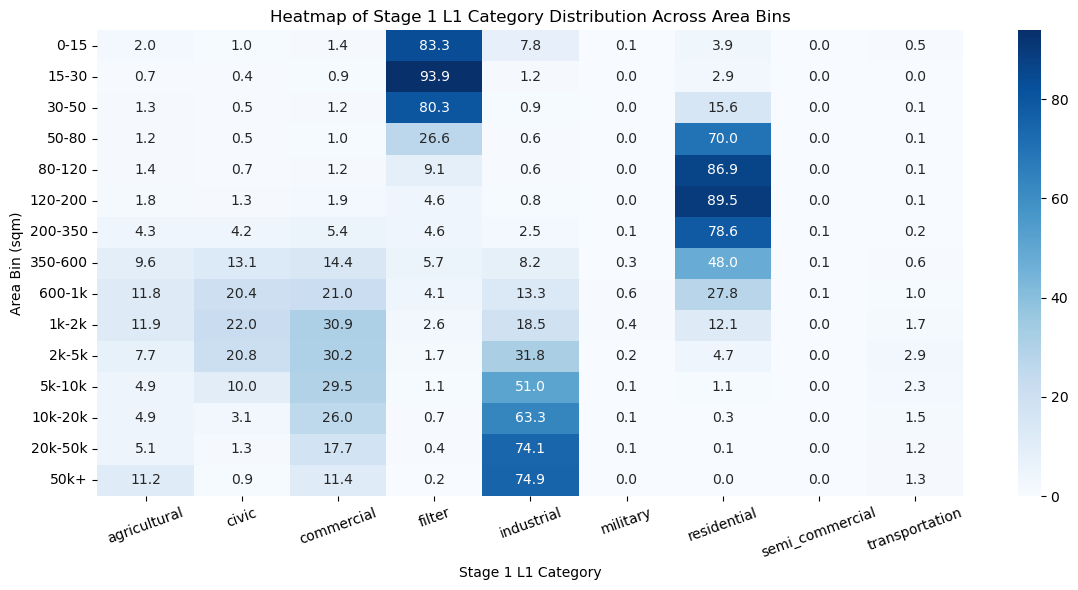

In [10]:
plt.figure(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title('Heatmap of Stage 1 L1 Category Distribution Across Area Bins')
plt.xlabel('Stage 1 L1 Category')
plt.ylabel('Area Bin (sqm)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

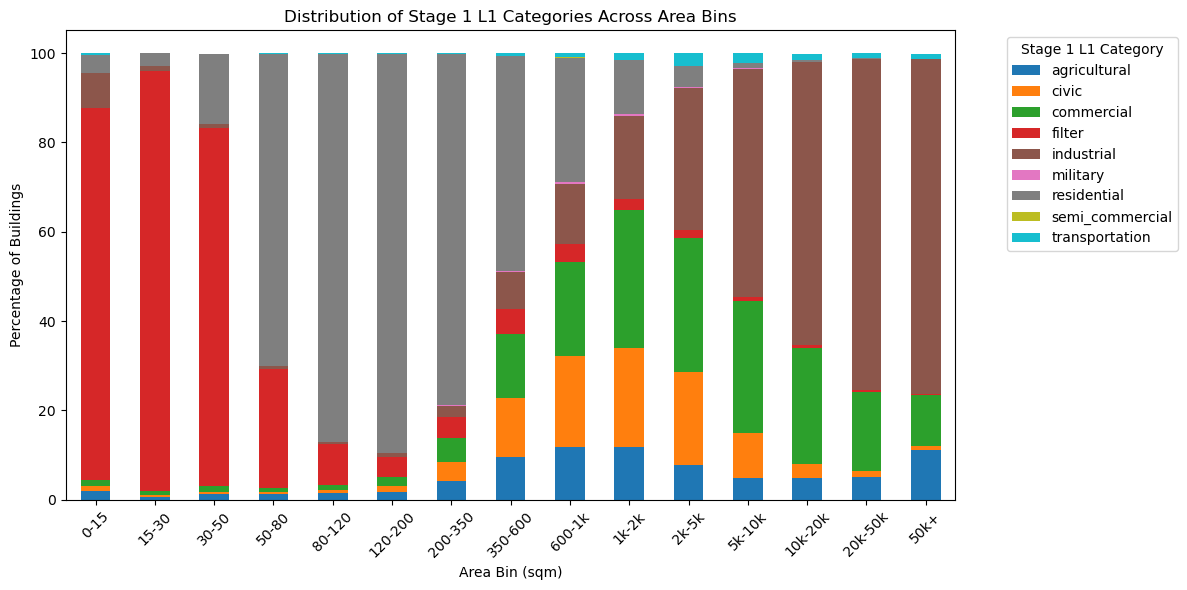

In [11]:
plt.figure(figsize=(12, 8))
ct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title('Distribution of Stage 1 L1 Categories Across Area Bins')
plt.xlabel('Area Bin (sqm)')
plt.ylabel('Percentage of Buildings')
plt.legend(title='Stage 1 L1 Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

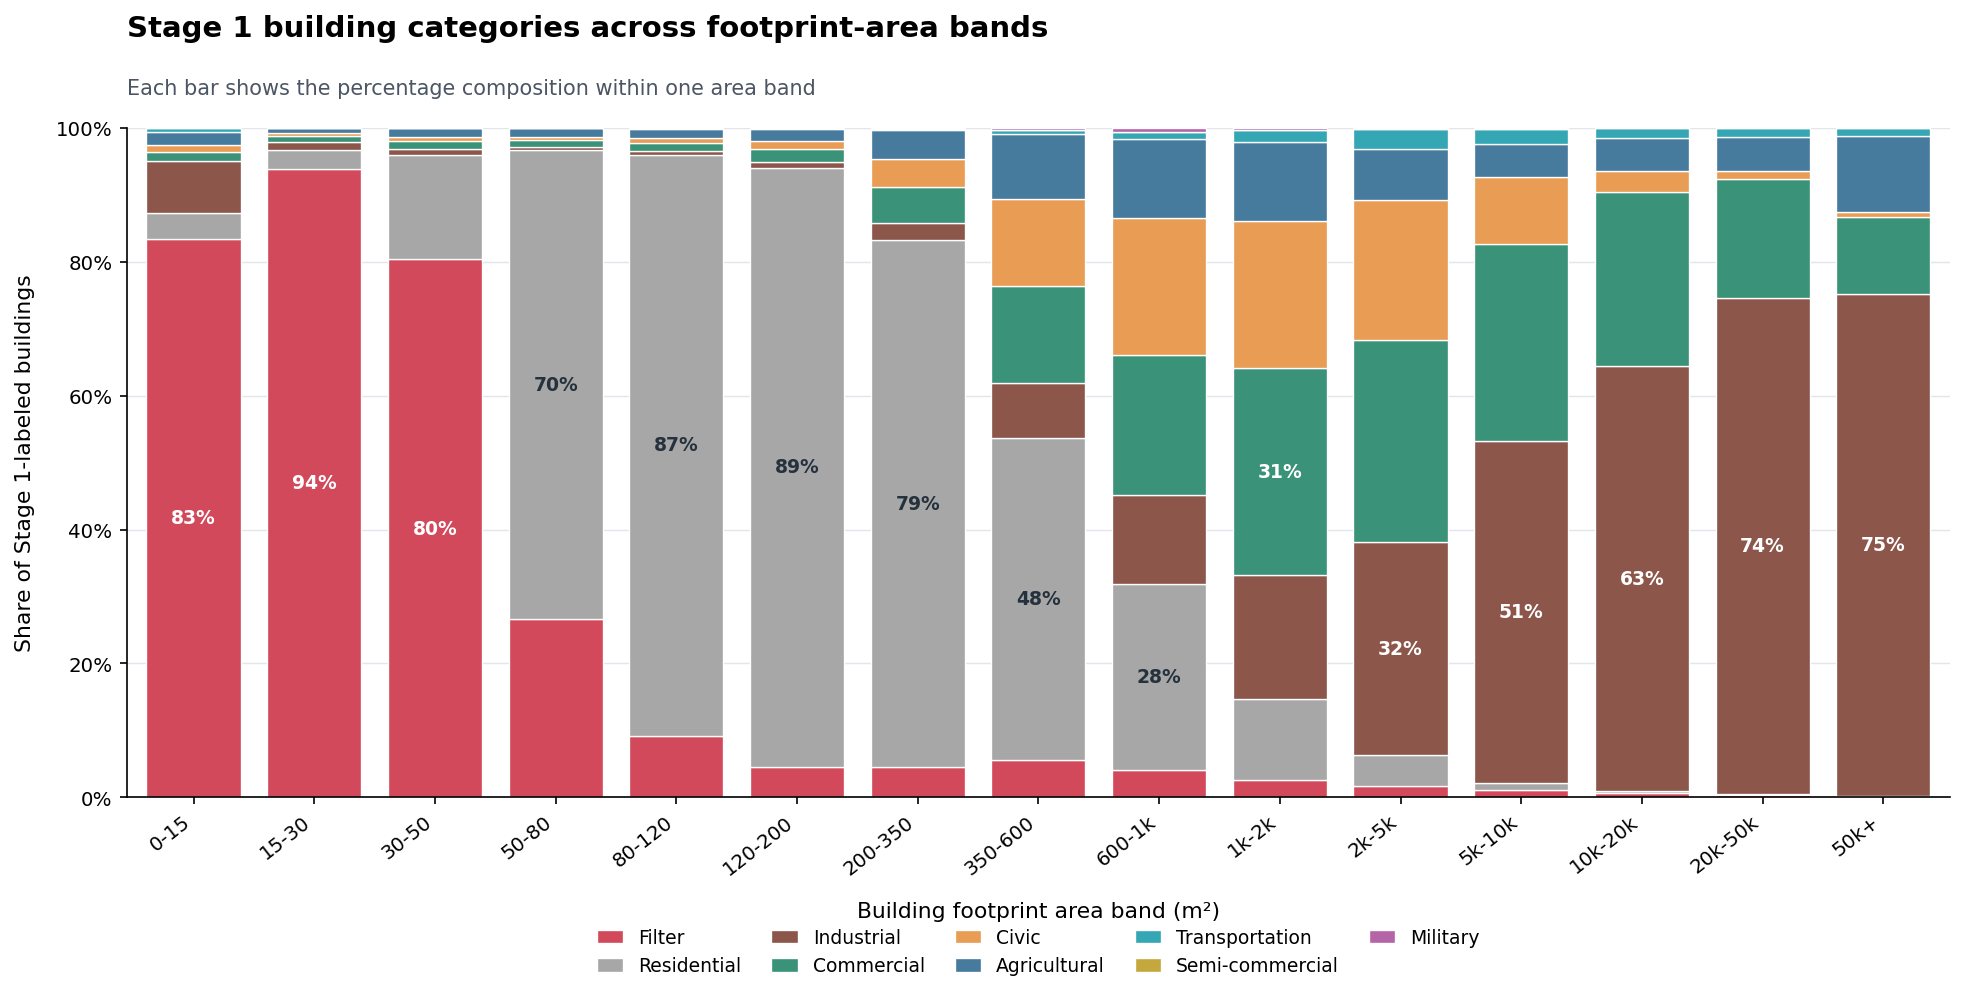

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

ct_plot = ct.copy()

# Convert values to percentages if ct contains counts or proportions
row_sums = ct_plot.sum(axis=1)

if np.isclose(row_sums.median(), 1, rtol=0.05):
    ct_plot = ct_plot * 100
elif not np.isclose(row_sums.median(), 100, rtol=0.05):
    ct_plot = ct_plot.div(row_sums, axis=0) * 100

# Use a logical ordering in both the stack and legend
preferred_order = [
    'filter',
    'residential',
    'industrial',
    'commercial',
    'civic',
    'agricultural',
    'transportation',
    'semi_commercial',
    'military'
]

column_order = (
    [column for column in preferred_order if column in ct_plot.columns]
    + [column for column in ct_plot.columns if column not in preferred_order]
)

ct_plot = ct_plot[column_order]

display_names = {
    'filter': 'Filter',
    'residential': 'Residential',
    'industrial': 'Industrial',
    'commercial': 'Commercial',
    'civic': 'Civic',
    'agricultural': 'Agricultural',
    'transportation': 'Transportation',
    'semi_commercial': 'Semi-commercial',
    'military': 'Military'
}

colors = {
    'filter': '#D1495B',
    'residential': '#A7A7A7',
    'industrial': '#8C564B',
    'commercial': '#3A9278',
    'civic': '#E89C54',
    'agricultural': '#477B9E',
    'transportation': '#35A7B4',
    'semi_commercial': '#C4A83E',
    'military': '#B565A7'
}

label_colors = {
    'filter': 'white',
    'residential': '#25313C',
    'industrial': 'white',
    'commercial': 'white',
    'civic': '#25313C',
    'agricultural': 'white',
    'transportation': '#25313C',
    'semi_commercial': '#25313C',
    'military': 'white'
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10.5,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False
})

fig, ax = plt.subplots(figsize=(13.5, 7.2))

x = np.arange(len(ct_plot))
bottom = np.zeros(len(ct_plot))

for category in column_order:
    values = ct_plot[category].to_numpy()

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.78,
        color=colors.get(category, '#B8BEC5'),
        edgecolor='white',
        linewidth=0.65,
        label=display_names.get(category, category.replace('_', ' ').title())
    )

    bottom += values

# Label only the dominant category in each area band
for i, (_, row) in enumerate(ct_plot.iterrows()):
    dominant_category = row.idxmax()
    dominant_value = row[dominant_category]
    category_position = column_order.index(dominant_category)
    lower_value = row[column_order[:category_position]].sum()

    ax.text(
        i,
        lower_value + dominant_value / 2,
        f'{dominant_value:.0f}%',
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
        color=label_colors.get(dominant_category, 'white')
    )

fig.suptitle(
    'Stage 1 building categories across footprint-area bands',
    x=0.085,
    y=0.975,
    ha='left',
    fontsize=14,
    fontweight='bold'
)

ax.set_title(
    'Each bar shows the percentage composition within one area band',
    loc='left',
    fontsize=10,
    fontweight='normal',
    color='#4B5563',
    pad=16
)

ax.set_xlabel('Building footprint area band (m²)', labelpad=11)
ax.set_ylabel('Share of Stage 1-labeled buildings', labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(ct_plot.index.astype(str), rotation=38, ha='right')

ax.set_ylim(0, 100)
ax.set_xlim(-0.55, len(ct_plot) - 0.45)
ax.yaxis.set_major_formatter(PercentFormatter(100))

ax.grid(
    axis='y',
    color='#D7DCE2',
    linewidth=0.7,
    alpha=0.7
)

ax.set_axisbelow(True)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.17),
    ncol=5,
    frameon=False,
    columnspacing=1.6,
    handlelength=1.4
)

fig.subplots_adjust(
    left=0.085,
    right=0.985,
    top=0.87,
    bottom=0.25
)



In [ ]:
# area bin cross-tab — shows % of each row that falls into each category
bins = [0, 15, 30, 50, 80, 120, 200, 350, 600, 1000, 2000, 5000, 10000, 20000, 50000, 999999]
labels = ['0-15','15-30','30-50','50-80','80-120','120-200','200-350','350-600','600-1k','1k-2k','2k-5k','5k-10k','10k-20k','20k-50k','50k+']


ct_subtypes = pd.crosstab(
    gdf_bldg['area_bin'],
    gdf_bldg['stage1_l2'],
    normalize='index'   
).round(3) * 100

print(ct_subtypes[['utilities','storage','manufacturing']])

stage1_l2  utilities  storage  manufacturing
area_bin                                    
0-15            53.9      0.3            0.3
15-30           23.4      0.7            0.5
30-50            5.8      0.5            0.3
50-80            0.8      0.2            0.1
80-120           0.5      0.2            0.1
120-200          0.5      0.2            0.1
200-350          1.1      0.5            0.1
350-600          2.3      1.3            0.4
600-1k           2.3      1.9            0.9
1k-2k            0.9      2.9            1.6
2k-5k            1.0      5.5            4.0
5k-10k           0.5     13.0            9.8
10k-20k          0.2     24.0           14.6
20k-50k          0.3     44.7           17.4
50k+             0.0     47.4           16.0


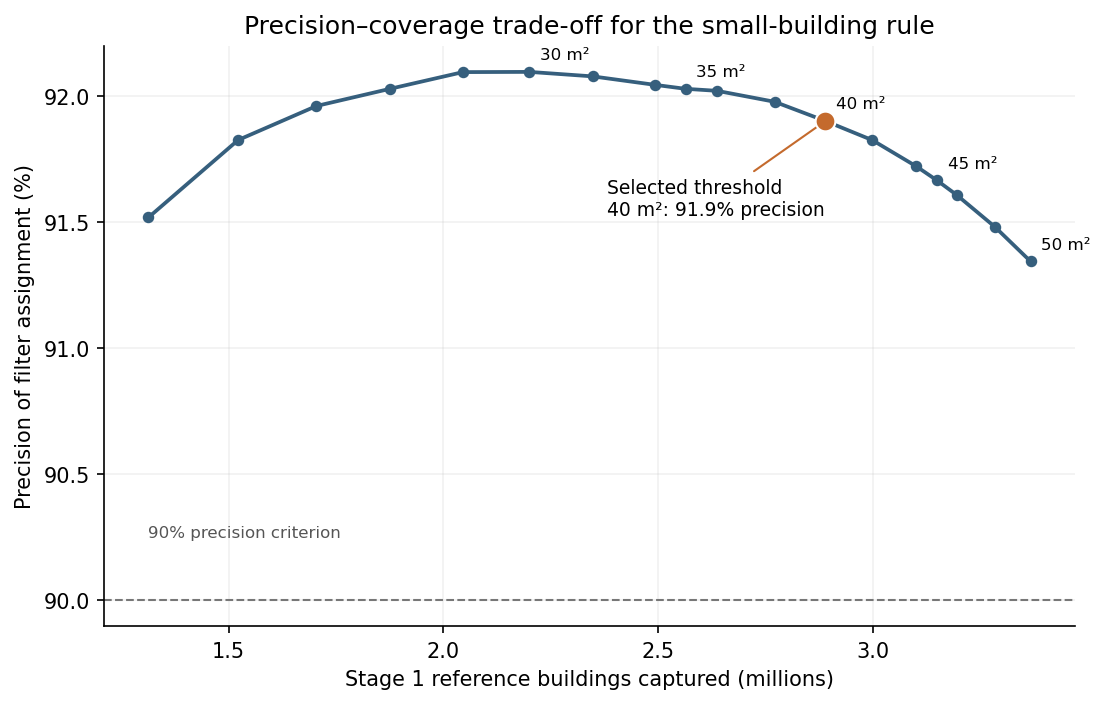

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

tagged = gdf_bldg[gdf_bldg['stage1_l1'].notna()].copy()
thresholds = sorted(set(range(20, 51, 2)) | {35, 40, 45, 50})

results = []
for threshold in thresholds:
    fired = tagged[(tagged['area_sqm'] < threshold) & (tagged['address_tier'] == 0)]
    results.append({
        'threshold': threshold,
        'precision': (fired['stage1_l1'] == 'filter').mean() * 100,
        'coverage': len(fired) / 1_000_000
    })

threshold_results = pd.DataFrame(results)
selected = threshold_results.loc[threshold_results['threshold'] == 40].iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(
    threshold_results['coverage'],
    threshold_results['precision'],
    marker='o',
    markersize=4.5,
    linewidth=1.8,
    color='#365F7D'
)

for threshold in [30, 35, 40, 45, 50]:
    row = threshold_results.loc[threshold_results['threshold'] == threshold].iloc[0]
    ax.annotate(
        f'{threshold} m²',
        (row['coverage'], row['precision']),
        xytext=(5, 6),
        textcoords='offset points',
        fontsize=8
    )

ax.scatter(
    selected['coverage'],
    selected['precision'],
    s=90,
    color='#C46A2D',
    edgecolor='white',
    linewidth=1,
    zorder=5
)

ax.axhline(90, color='#777777', linestyle='--', linewidth=1)
ax.text(
    threshold_results['coverage'].min(),
    90.25,
    '90% precision criterion',
    color='#555555',
    fontsize=8
)

ax.set_xlabel('Stage 1 reference buildings captured (millions)')
ax.set_ylabel('Precision of filter assignment (%)')
ax.set_title('Precision–coverage trade-off for the small-building rule')
ax.grid(axis='both', alpha=0.18)

ax.annotate(
    f"Selected threshold\n40 m²: {selected['precision']:.1f}% precision",
    xy=(selected['coverage'], selected['precision']),
    xytext=(-105, -45),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='-', color='#C46A2D'),
    fontsize=9
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1592517/647112419.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


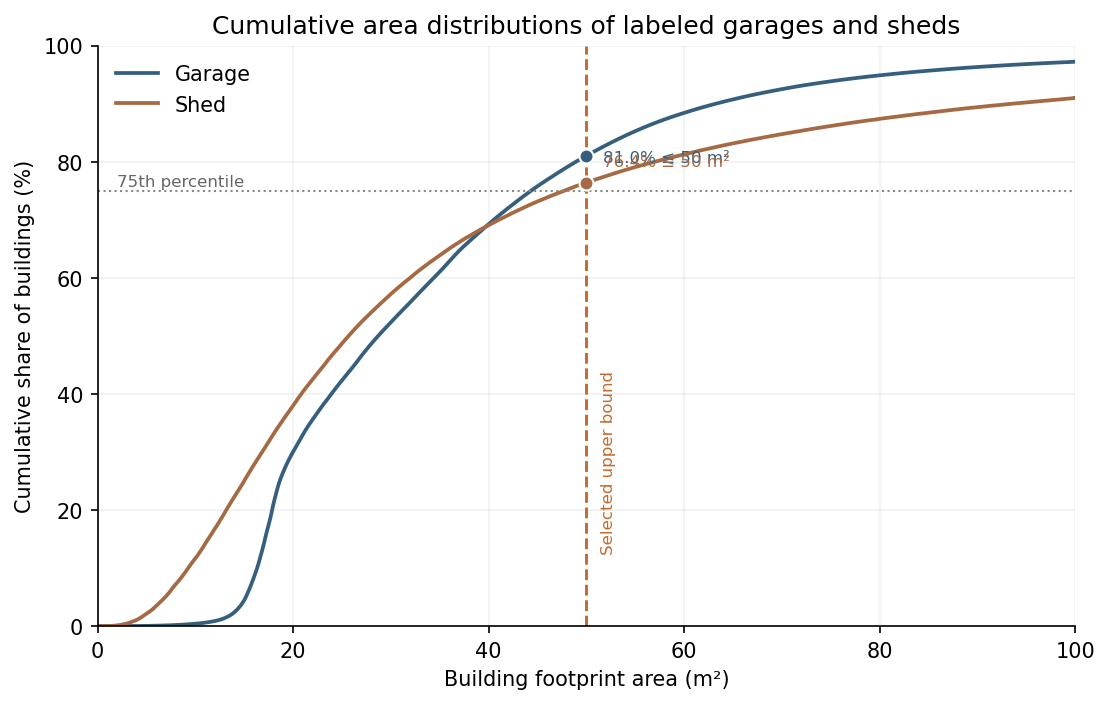

In [14]:
garage_shed_data = {
    'Garage': tagged.loc[tagged['raw_label'] == 'garage', 'area_sqm'].dropna(),
    'Shed': tagged.loc[tagged['raw_label'] == 'shed', 'area_sqm'].dropna()
}

fig, ax = plt.subplots(figsize=(7.5, 4.8))
colors = {'Garage': '#365F7D', 'Shed': '#A56A43'}

for label, values in garage_shed_data.items():
    x = np.sort(values.to_numpy())
    y = np.arange(1, len(x) + 1) / len(x) * 100
    share_50 = (values <= 50).mean() * 100

    ax.step(x, y, where='post', linewidth=1.8, color=colors[label], label=label)
    ax.scatter(50, share_50, s=45, color=colors[label], edgecolor='white', zorder=5)
    ax.annotate(
        f'{share_50:.1f}% ≤ 50 m²',
        (50, share_50),
        xytext=(8, -3 if label == 'Garage' else 8),
        textcoords='offset points',
        fontsize=8,
        color=colors[label]
    )

ax.axvline(50, color='#C46A2D', linestyle='--', linewidth=1.4)
ax.axhline(75, color='#888888', linestyle=':', linewidth=1)
ax.text(51.5, 13, 'Selected upper bound', color='#C46A2D', fontsize=8, rotation=90)
ax.text(2, 75.8, '75th percentile', color='#666666', fontsize=8)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('Building footprint area (m²)')
ax.set_ylabel('Cumulative share of buildings (%)')
ax.set_title('Cumulative area distributions of labeled garages and sheds')
ax.legend(frameon=False)
ax.grid(axis='both', alpha=0.18)

plt.tight_layout()
plt.show()

We can classify buildings where >85% dominate.

- zoom in to 0-50 for classifying filters
- zoom in to 80 - 350 for residential


In [15]:
# zoom in cross-tab to areas between 0 and 50 to jutify cutoff rule for filter
filter_bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
filter_labels = ['0-5','5-10','10-15','15-20','20-25','25-30','30-35','35-40','40-45','45-50']

gdf_bldg['filter_area_bin'] = pd.cut(gdf_bldg['area_sqm'], bins=filter_bins, labels=filter_labels)

ct_filter = pd.crosstab(
    gdf_bldg['filter_area_bin'],
    gdf_bldg['stage1_l1'],
    normalize='index'   # shows % of each row
).round(3) * 100

print(ct_filter[['filter','residential','commercial','industrial','civic','agricultural']])



stage1_l1        filter  residential  commercial  industrial  civic  \
filter_area_bin                                                       
0-5                81.2          4.3         1.5         7.5    1.2   
5-10               77.7          4.0         1.6        11.8    1.2   
10-15              86.9          3.7         1.3         5.6    0.8   
15-20              95.5          1.7         0.7         1.2    0.3   
20-25              92.8          3.4         1.1         1.2    0.4   
25-30              91.7          4.5         1.1         1.0    0.5   
30-35              89.5          6.8         1.2         0.9    0.5   
35-40              85.4         10.6         1.2         0.9    0.5   
40-45              76.7         19.0         1.3         0.9    0.6   
45-50              66.1         29.6         1.3         0.8    0.6   

stage1_l1        agricultural  
filter_area_bin                
0-5                       3.2  
5-10                      2.7  
10-15              

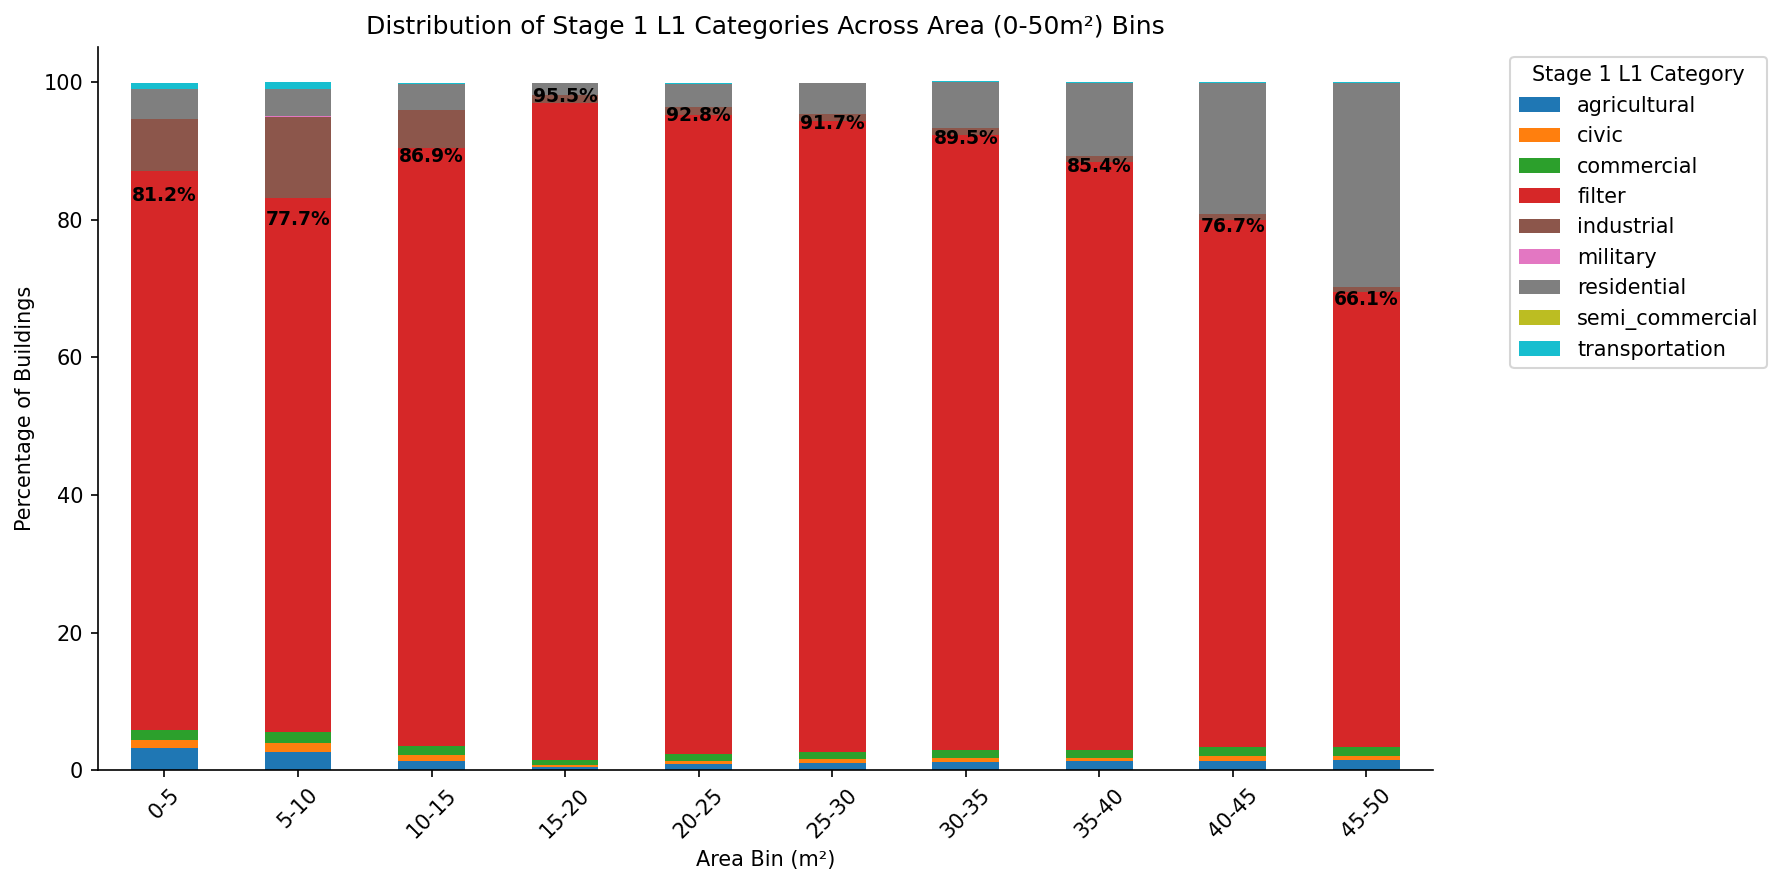

In [16]:
ax = ct_filter.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')

for i, val in enumerate(ct_filter['filter']):
    ax.text(
        i, 
        val + 1,                 # slightly above the bar segment
        f"{val:.1f}%", 
        ha='center', 
        va='bottom', 
        fontsize=9,
        fontweight='bold'
    )

plt.title('Distribution of Stage 1 L1 Categories Across Area (0-50m²) Bins')
plt.xlabel('Area Bin (m²)')
plt.ylabel('Percentage of Buildings')
plt.legend(title='Stage 1 L1 Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

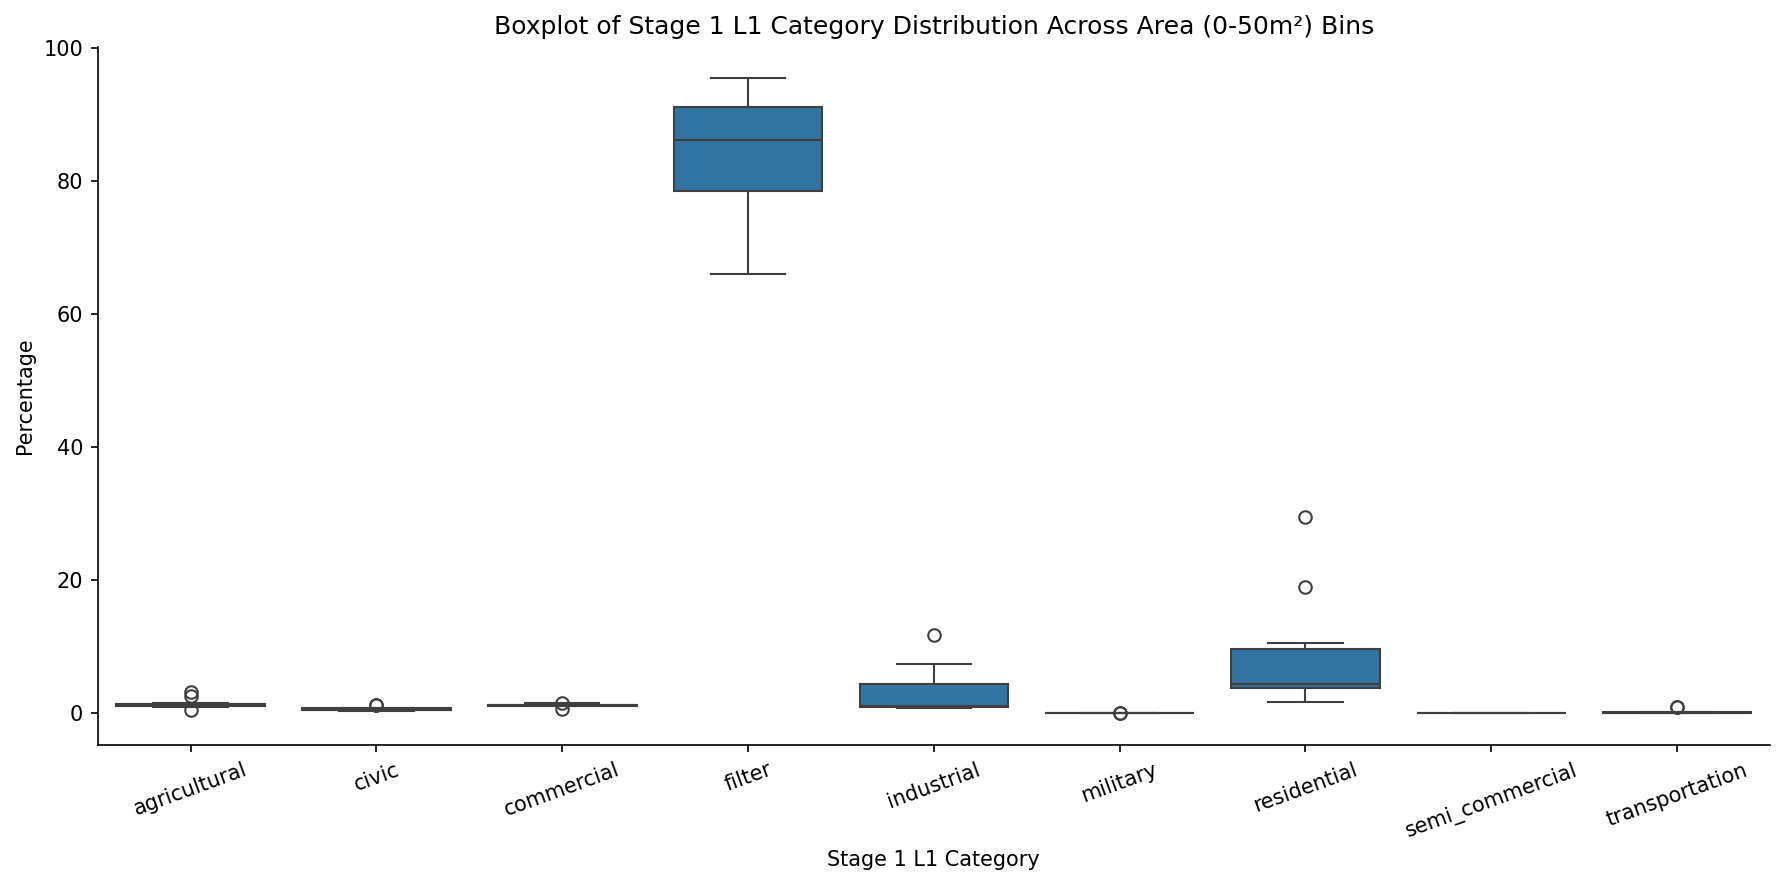

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=ct_filter.melt(var_name='Stage 1 L1 Category', value_name='Percentage'), x='Stage 1 L1 Category', y='Percentage')
plt.title('Boxplot of Stage 1 L1 Category Distribution Across Area (0-50m²) Bins')
plt.xlabel('Stage 1 L1 Category')
plt.ylabel('Percentage')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

We can filter out buildings with an area less than 35/40m² and despite some small buildings falling in that category, the filter category will be overriden if they fall in an industrial landuse zone

In [18]:
# Check how many filter buildings have an address
total_filter = len(filter_bldgs)
with_address = len(filter_bldgs[filter_bldgs['address_tier'] != 0])
percentage = (with_address / total_filter * 100) if total_filter > 0 else 0

print(f"Total filter buildings: {total_filter}")
print(f"Filter buildings with address: {with_address}")
print(f"Percentage of filter buildings with address: {percentage:.2f}%")

Total filter buildings: 4121244
Filter buildings with address: 62100
Percentage of filter buildings with address: 1.51%


In [19]:
# inspectin filtered buildings with an address to see if they look like they should be filters or not
filter_bldgs[(filter_bldgs['address_tier'] != 0)][['id', 'building','raw_label', 'area_sqm', 'stage1_l1', 'stage1_l2', 'address_tier']].sample(30)  

,id,building,raw_label,area_sqm,stage1_l1,stage1_l2,address_tier
29540922,745263118,garage,garage,20.560610,filter,None,1
14769052,290613602,allotment_house,allotment_house,29.800473,filter,None,2
15091965,294732166,garage,garage,40.781157,filter,None,2
29870106,766039536,shed,shed,25.062446,filter,None,2
2247951,98978826,roof,roof,96.621525,filter,None,2
33280742,995007617,hut,hut,67.565419,filter,None,2
17773676,324276314,shed,shed,21.687664,filter,None,1
9750018,228652865,garage,garage,29.193546,filter,None,1
24429435,475460329,garage,garage,54.323167,filter,None,2
3345210,119658838,garage,garage,40.707607,filter,None,1


In [20]:
# Filter buildings with area between 0 and 40 sqm
small_buildings = filter_bldgs[(gdf_bldg['area_sqm'] > 0) & (gdf_bldg['area_sqm'] <= 40)]

# Calculate percentage with address (assuming address_tier indicates presence of address)
total_small = len(small_buildings)
without_address = len(small_buildings[small_buildings['address_tier'] == 0])
percentage = (without_address / total_small * 100) if total_small > 0 else 0

print(f"Total buildings 0-40 sqm: {total_small}")
print(f"Buildings 0-40 sqm with address: {total_small - without_address}")
print(f"Percentage of currently filtered 0-40sqm \nbuildings without address: {percentage:.2f}%")

/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


Total buildings 0-40 sqm: 2684170
Buildings 0-40 sqm with address: 28743
Percentage of currently filtered 0-40sqm 
buildings without address: 98.93%


In [21]:
small_buildings[(small_buildings['address_tier'] != 0)][['id', 'building','raw_label', 'area_sqm', 'stage1_l1', 'stage1_l2', 'address_tier']].sample(30)  

,id,building,raw_label,area_sqm,stage1_l1,stage1_l2,address_tier
4902762,147844160,garage,garage,14.329809,filter,None,2
25297767,503541610,garage,garage,18.260817,filter,None,1
3211975,117680271,garage,garage,20.931400,filter,None,1
33987899,1024671683,garage,garage,22.125296,filter,None,2
16125525,306443635,garage,garage,21.076190,filter,None,1
34221560,1034434733,shed,shed,31.187198,filter,None,1
36601967,1230341858,garage,garage,20.421810,filter,None,1
11270468,248994762,tower,tower,23.141417,filter,None,2
24607866,480459851,garage,garage,36.947394,filter,None,1
38157392,1429212724,allotment_house,allotment_house,25.120441,filter,None,1


In [22]:
# Filter buildings with area between 0 and 40 sqm
small_buildings = gdf_bldg[(gdf_bldg['area_sqm'] > 0) & (gdf_bldg['area_sqm'] <= 40)]

# Calculate percentage with address (assuming address_tier indicates presence of address)
total_small = len(small_buildings)
without_address = len(small_buildings[small_buildings['address_tier'] == 0])
percentage = (without_address / total_small * 100) if total_small > 0 else 0

print(f"Percentage of buildings 0-40 sqm without address: {percentage:.2f}%")
print(f"Total buildings 0-40 sqm: {total_small}")
print(f"Buildings 0-40 sqm with address: {total_small - without_address}")

Percentage of buildings 0-40 sqm without address: 97.94%
Total buildings 0-40 sqm: 8696042
Buildings 0-40 sqm with address: 179463


In [23]:
# Calculate percentage of small buildings that can be classified as 'filter'
len(small_buildings[small_buildings['stage1_l1'].isna()])/len(gdf_bldg)

0.14775465273102376

Only 1.5% of filtered buildings have an address, so it is safe to assume that a small building without an address should be filtered. This rule would be applied to 97.94% of buildings less than 40sqm. 

In [24]:
tagged = gdf_bldg[gdf_bldg['stage1_l1'].notna()].copy()

# Simulate the rule on tagged buildings
fired = tagged[
    (tagged['area_sqm'] < 40) & 
    (tagged['address_tier'] == 0)
]

precision = (fired['stage1_l1'] == 'filter').mean()
total_fired = len(fired)
rescued = tagged[
    (tagged['area_sqm'] < 40) & 
    (tagged['address_tier'] >= 1)
].shape[0]

print(f"Rule precision : {precision:.1%}")
print(f"Fires on       : {total_fired:,} tagged buildings")
print(f"Rescued (addr) : {rescued:,} small buildings kept alive")

# What are the false positives?
fp = fired[fired['stage1_l1'] != 'filter']
print(f"\nFalse positives: {len(fp):,} ({len(fp)/total_fired:.1%})")
print(fp['stage1_l1'].value_counts())

Rule precision : 91.9%
Fires on       : 2,889,391 tagged buildings
Rescued (addr) : 73,420 small buildings kept alive

False positives: 233,964 (8.1%)
stage1_l1
residential        96403
industrial         60158
agricultural       31293
commercial         28216
civic              13472
transportation      3767
military             651
semi_commercial        4
Name: count, dtype: int64


In [25]:
small_residential = tagged[
    (tagged['area_sqm'] < 1) & 
    (tagged['address_tier'] == 0) &
    (tagged['stage1_l1'] == 'residential')
]

print(small_residential['raw_label'].value_counts().head(15))
print(small_residential['stage1_l2'].value_counts().head(15))

raw_label
house                 22
residential           14
cabin                 14
apartments            12
detached               5
terrace                4
semidetached_house     4
farm                   1
Name: count, dtype: int64
stage1_l2
SFH    24
MFH    12
TH      4
Name: count, dtype: int64


In [26]:
tagged = gdf_bldg[gdf_bldg['stage1_l1'].notna()].copy()

# Simulate the rule on tagged buildings
fired = tagged[
    (tagged['area_sqm'] < 35) & 
    (tagged['address_tier'] == 0)
]

precision = (fired['stage1_l1'] == 'filter').mean()
total_fired = len(fired)
rescued = tagged[
    (tagged['area_sqm'] < 35) & 
    (tagged['address_tier'] >= 1)
].shape[0]

print(f"Rule precision : {precision:.1%}")
print(f"Fires on       : {total_fired:,} tagged buildings")
print(f"Rescued (addr) : {rescued:,} small buildings kept alive")


Rule precision : 92.0%
Fires on       : 2,563,627 tagged buildings
Rescued (addr) : 47,620 small buildings kept alive


In [27]:
# check small residential buildings with an address to see if they look like they should be filters or not
small_residential_with_address = tagged[
    (tagged['area_sqm'] < 40) & 
    (tagged['address_tier'] >= 1) &
    (tagged['stage1_l1'] == 'residential')
]  

small_residential_with_address[['id','building','raw_label','stage1_l1','stage1_l2','address_tier']]

,id,building,raw_label,stage1_l1,stage1_l2,address_tier
25163,24921800,apartments,apartments,residential,MFH,1
29868,25382799,house,house,residential,None,2
29873,25382835,house,house,residential,None,2
29883,25382882,house,house,residential,None,2
30387,25450297,house,house,residential,None,2
...,...,...,...,...,...,...
38794608,1489581888,house,terraced,residential,TH,2
38796291,1489774421,semidetached_house,semidetached_house,residential,SFH,2
38801878,1490292896,apartments,apartments,residential,MFH,2
38801879,1490292897,apartments,apartments,residential,MFH,2


Running the rule on already tagged buildings we have a precision of 91.6%. The false positives for residential indicate bad input data except maybe cabin or farm, however these are low energy demand buildings. Other kinds of residential buildings are questionable, especially apartments, as it's very unlikely a mfh has an area of 40m².

Also, reducing the cutoff area to 35m² only increases the precision by 0.1%, so a cut off area of 40m² is good

In [28]:
addressed_bldgs = gdf_bldg[gdf_bldg['address_tier'] > 0]

In [ ]:
# zoom in cross-tab to areas between 80 and 350 to inspect rule for residential buildings
res_bins = [80, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350] 
res_labels = ['80-100','100-125','125-150','150-175','175-200','200-225','225-250','250-275','275-300','300-325','325-350']

addressed_bldgs['res_area_bin'] = pd.cut(addressed_bldgs['area_sqm'], bins=res_bins, labels=res_labels)

ct_res = pd.crosstab(
    addressed_bldgs['res_area_bin'],
    addressed_bldgs['stage1_l1'],
    normalize='index'  
).round(3) * 100

print(ct_res[['filter','residential','commercial','industrial','civic','agricultural']])

/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


stage1_l1     filter  residential  commercial  industrial  civic  agricultural
res_area_bin                                                                  
80-100           0.4         98.3         0.7         0.1    0.3           0.1
100-125          0.3         98.0         1.0         0.1    0.5           0.1
125-150          0.3         97.4         1.3         0.1    0.7           0.1
150-175          0.2         96.8         1.7         0.2    1.0           0.1
175-200          0.2         95.7         2.2         0.3    1.4           0.1
200-225          0.2         94.1         3.0         0.4    2.0           0.1
225-250          0.3         91.7         4.1         0.6    2.9           0.2
250-275          0.3         88.5         5.8         0.9    4.1           0.3
275-300          0.3         84.7         7.6         1.2    5.5           0.4
300-325          0.4         79.9         9.8         1.9    7.3           0.5
325-350          0.4         75.4        11.7       

80 - 250m² buildings have a 90% chance of bein residential

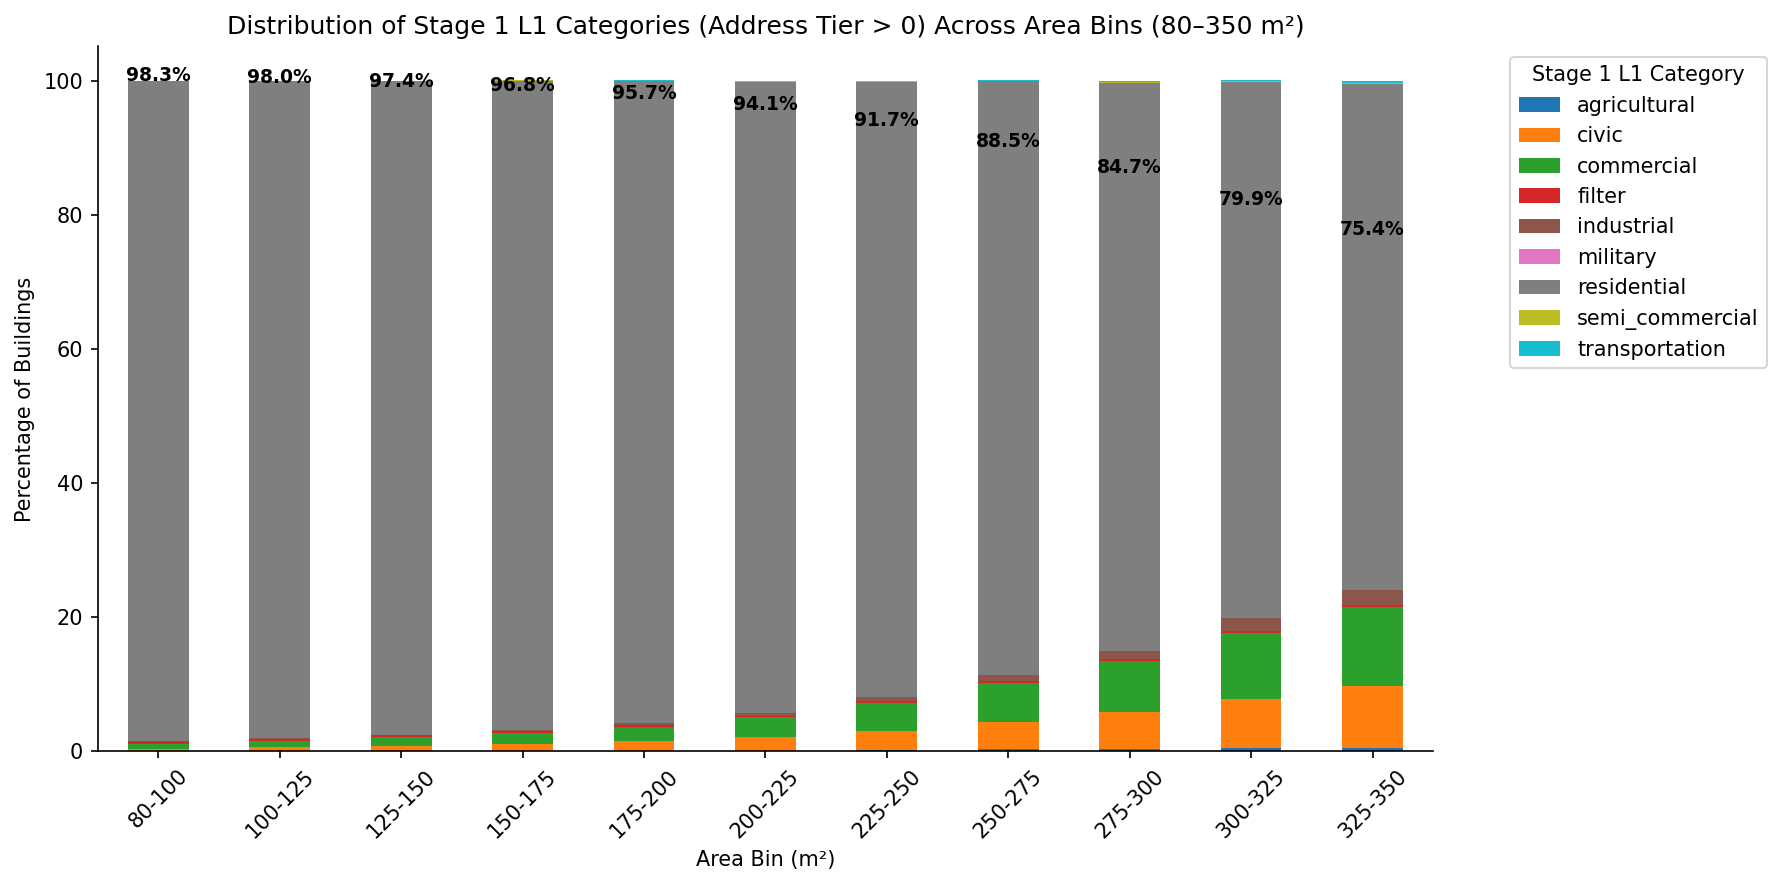

In [30]:
ax = ct_res.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')

# Add labels only for residential
for i, val in enumerate(ct_res['residential']):
    ax.text(
        i, 
        val + 1,                 # slightly above the bar segment
        f"{val:.1f}%", 
        ha='center', 
        va='bottom', 
        fontsize=9,
        fontweight='bold'
    )


plt.title('Distribution of Stage 1 L1 Categories (Address Tier > 0) Across Area Bins (80–350 m²)')
plt.xlabel('Area Bin (m²)')
plt.ylabel('Percentage of Buildings')
plt.legend(title='Stage 1 L1 Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


If a building is in the typical residential size range (80-200) and has full address information attached to it, it is >95% certainly a home

In [31]:
# Simulate the residential rule on tagged buildings
res_fired = tagged[
    (tagged['area_sqm'].between(80, 200)) &     
    (tagged['address_tier'] >= 1)
]

res_precision = (res_fired['stage1_l1'] == 'residential').mean()
total_res_fired = len(res_fired)
res_rescued = tagged[
    (tagged['area_sqm'].between(80, 200)) &     
    (tagged['address_tier'] < 1)
].shape[0]

print(f"Rule precision : {res_precision:.1%}")
print(f"Fires on : {total_res_fired:,} tagged buildings")
print(f"Rescued (addr) : {res_rescued:,} buildings \nnot tagged residential")

# What are the false positives?
fp = res_fired[res_fired['stage1_l1'] != 'residential']
print(f"\nFalse positives: {len(fp):,} ({len(fp)/total_res_fired:.1%})")
print(fp['stage1_l1'].value_counts())

Rule precision : 97.4%
Fires on : 4,096,308 tagged buildings
Rescued (addr) : 1,129,733 buildings 
not tagged residential

False positives: 104,623 (2.6%)
stage1_l1
commercial         51203
civic              28366
filter             12048
industrial          6347
agricultural        3431
semi_commercial     1903
transportation      1114
military             211
Name: count, dtype: int64


97.7% precision on ground truth data with the rule 'area between 80 and 175 + address_tier = 2' with 2.3% false positives. However precision might be high due to the dominance of residential buildings. Applying this rule after POI-based and zone-based rules should eliminate most of those false positives before the rule fires.

In [32]:
print(f"Percentage of commercial false positives over total commercial buildings: {(len(fp[fp['stage1_l1'] == 'commercial']))/len(gdf_bldg[gdf_bldg['stage1_l1'] == 'commercial']):.1%}")

Percentage of commercial false positives over total commercial buildings: 12.1%


In [33]:
print(f"Percentage of civic false positives over total civic buildings: {(len(fp[fp['stage1_l1'] == 'civic']))/len(gdf_bldg[gdf_bldg['stage1_l1'] == 'civic']):.1%}")

Percentage of civic false positives over total civic buildings: 9.1%


### Garage Analysis

In [34]:
# check the average size of garages in raw_label
garages = tagged[tagged['raw_label'] == 'garage']
print(f"Average area of buildings labeled as 'garage': {garages['area_sqm'].mean():.2f} sqm")

Average area of buildings labeled as 'garage': 36.98 sqm


In [35]:
garages.area_sqm.describe().round(2)

count    2526027.00
mean          36.98
std           40.43
min            0.17
25%           18.63
50%           28.71
75%           44.35
max        14108.31
Name: area_sqm, dtype: float64

In [36]:
# check the average size of sheds in raw_label
sheds = tagged[tagged['raw_label'] == 'shed']
print(f"Average area of buildings labeled as 'shed': {sheds['area_sqm'].mean():.2f} sqm")
sheds.area_sqm.describe().round(2)

Average area of buildings labeled as 'shed': 45.76 sqm


count    455075.00
mean         45.76
std          80.29
min           0.22
25%          14.99
50%          25.68
75%          47.76
max        7681.06
Name: area_sqm, dtype: float64

Analysis of OSM-labeled buildings shows that garage structures have a mean area of 36.9 m² and a 75th percentile of 44.3 m², with similar distributions observed for sheds. Based on this, a threshold of 50 m² was selected as a conservative upper bound for identifying small auxiliary structures.

Additionally, buildings smaller than 40 m² without address information were already filtered in a previous step. Therefore, this rule specifically targets buildings in the 40–50 m² range, ensuring that slightly larger garage-like structures are also captured while avoiding overlap with earlier filtering.

In [37]:
# Work only with already-tagged buildings as test set
tagged = gdf_bldg[gdf_bldg['stage1_l1'].notna()].copy()

# Candidate garages: small, no address, unclassified buildings
# We test on tagged ones so we can measure precision
candidate_garages = tagged[(tagged['area_sqm'].between(40,50))
                           & (tagged['address_tier'] == 0)].copy()

# Addressed neighbours: any building with a full or partial address
addressed_bldgs = tagged[
    (tagged['address_tier'] >= 1)
][['geometry', 'id', 'address_tier', 'stage1_l1']].copy()

print(f"Candidate small unaddressed buildings: {len(candidate_garages):,}")
print(f"Addressed buildings to check against : {len(addressed_bldgs):,}")

Candidate small unaddressed buildings: 477,735
Addressed buildings to check against : 7,046,949


In [ ]:
# How many buildings would the cluster rule catch that the area+address rule MISSED?
# These are the only ones worth caring about

already_filtered_by_rule1 = (
    (gdf_bldg['area_sqm'] < 40) & 
    (gdf_bldg['address_tier'] == 0) &
    (gdf_bldg['stage1_l1'].isna())
)

# Cluster rule candidates: small, no address, BUT not caught by rule 1
# This means either area >= 40 OR they have an address
additional_candidates = gdf_bldg[
    ~already_filtered_by_rule1 &
    (gdf_bldg['area_sqm'] < 50) &      
    (gdf_bldg['address_tier'] == 0) &
    (gdf_bldg['stage1_l1'].isna())     
]

print(f"Buildings rule 1 would filter       : {already_filtered_by_rule1.sum():,}")
print(f"Additional candidates for cluster   : {len(additional_candidates):,}")
print(f"% additional vs rule 1              : {len(additional_candidates)/already_filtered_by_rule1.sum()*100:.1f}%")

Buildings rule 1 would filter       : 5,627,188
Additional candidates for cluster   : 1,245,241
% additional vs rule 1              : 22.1%


In [ ]:
# What does the 40-50m² + no address unclassified pool actually look like?
additional_candidates = gdf_bldg[
    (gdf_bldg['area_sqm'].between(40,50)) &
    (gdf_bldg['address_tier'] == 0) &
    (gdf_bldg['stage1_l1'].isna())
]

# What building tags do they have?
print("Building tags:")
print(additional_candidates['building'].value_counts().head(15))

# Area distribution within this pool
print("\nArea distribution:")
bins = [40,42,44,46,48,50]
print(additional_candidates['area_sqm'].value_counts(
    bins=bins, normalize=True
).sort_index() * 100)

# Cross check on TAGGED buildings in this same band
# to see what the true type distribution looks like
tagged_band = gdf_bldg[
    (gdf_bldg['area_sqm'].between(40, 50)) &
    (gdf_bldg['address_tier'] == 0) &
    (gdf_bldg['stage1_l1'].notna())
]
print("\nType distribution in 40-50m² + no address (tagged buildings):")
print(tagged_band['stage1_l1'].value_counts(normalize=True).round(3) * 100)

Building tags:
building
yes               1242504
service              2256
silo                  209
construction          105
proposed               25
bakehouse              22
depot                  17
workshop                6
gazebo                  5
historic                5
prefabricated           4
railway                 3
utility                 3
cellar                  3
animal_shelter          3
Name: count, dtype: int64

Area distribution:
(39.999, 42.0]    22.035975
(42.0, 44.0]      21.102100
(44.0, 46.0]      19.797292
(46.0, 48.0]      19.001864
(48.0, 50.0]      18.062769
Name: proportion, dtype: float64

Type distribution in 40-50m² + no address (tagged buildings):
stage1_l1
filter             88.0
residential         7.4
agricultural        1.8
commercial          1.3
industrial          0.9
civic               0.6
transportation      0.1
military            0.0
semi_commercial     0.0
Name: proportion, dtype: float64


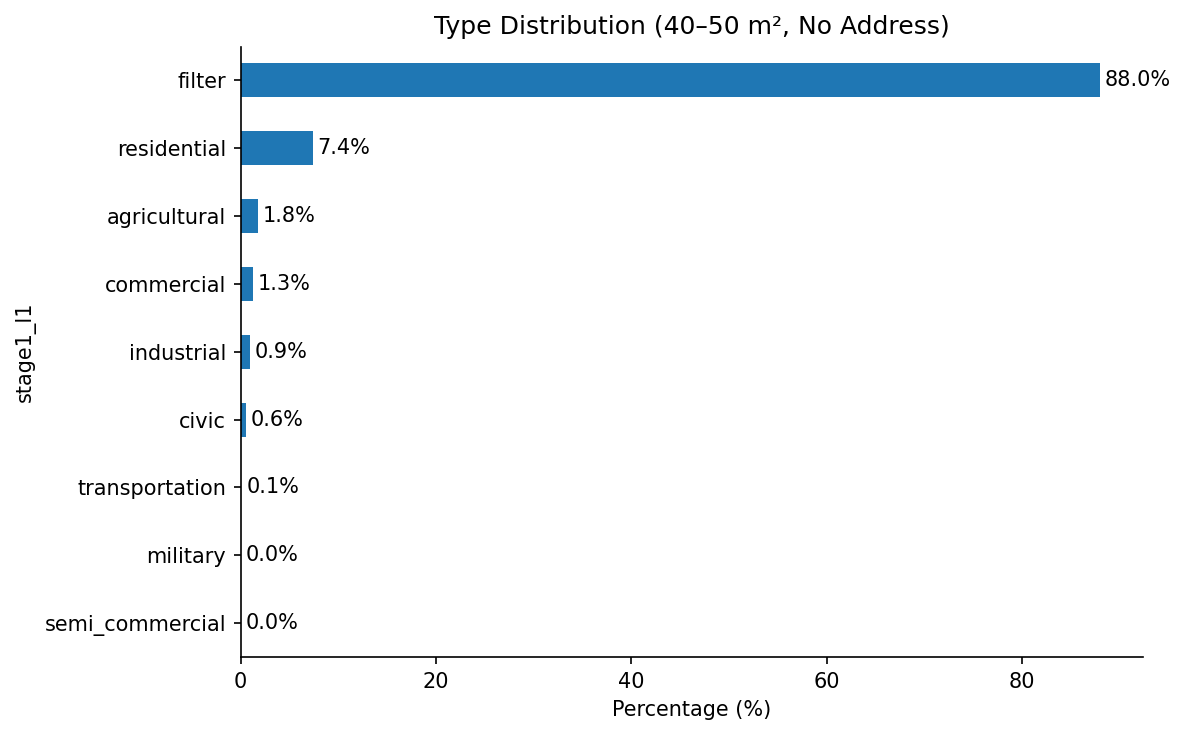

In [40]:
dist = tagged_band['stage1_l1'].value_counts(normalize=True) * 100

dist = dist.sort_values()

plt.figure(figsize=(8,5))
dist.plot(kind='barh')

for i, v in enumerate(dist):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.xlabel('Percentage (%)')
plt.title('Type Distribution (40–50 m², No Address)')
plt.tight_layout()
plt.show()

In [41]:
# Quick proxy test: on TAGGED buildings in this band

tagged_band = tagged_band.to_crs(epsg=3035)

addressed_residential = gdf_bldg[
    (gdf_bldg['address_tier'] == 2) &
    (gdf_bldg['stage1_l1'] == 'residential')
][['geometry', 'id']].copy()

addressed_residential = addressed_residential.to_crs(epsg=3035)

# sjoin_nearest finds any addressed residential building within 5 meters
joined = gpd.sjoin_nearest(
    tagged_band[['geometry', 'id', 'stage1_l1']],
    addressed_residential[['geometry', 'id']],
    how='left', max_distance=5, distance_col='dist_to_house',
    lsuffix='g', rsuffix='n'
)
joined = joined[joined['id_g'] != joined['id_n']]

has_neighbour = joined.groupby('id_g')['id_n'].count() > 0
tagged_band['has_addressed_neighbour'] = (
    tagged_band['id'].isin(has_neighbour[has_neighbour].index)
)

# Compare precision: with vs without addressed neighbour
with_neighbour    = tagged_band[tagged_band['has_addressed_neighbour']]
without_neighbour = tagged_band[~tagged_band['has_addressed_neighbour']]

print("Base rate (no spatial check):")
print(f"  filter: {(tagged_band['stage1_l1']=='filter').mean():.1%}")
print(f"  n     : {len(tagged_band):,}")

print("\nWITH addressed neighbour:")
print(f"  filter: {(with_neighbour['stage1_l1']=='filter').mean():.1%}")
print(f"  n     : {len(with_neighbour):,}")

print("\nWITHOUT addressed neighbour:")
print(f"  filter: {(without_neighbour['stage1_l1']=='filter').mean():.1%}")
print(f"  n     : {len(without_neighbour):,}")

# Type breakdown for each group
print("\nType breakdown WITH neighbour:")
print(with_neighbour['stage1_l1'].value_counts(normalize=True).round(3) * 100)

print("\nType breakdown WITHOUT neighbour:")
print(without_neighbour['stage1_l1'].value_counts(normalize=True).round(3) * 100)

Base rate (no spatial check):
  filter: 88.0%
  n     : 477,735

WITH addressed neighbour:
  filter: 94.9%
  n     : 159,381

WITHOUT addressed neighbour:
  filter: 84.5%
  n     : 318,354

Type breakdown WITH neighbour:
stage1_l1
filter            94.9
residential        4.0
agricultural       0.6
commercial         0.3
industrial         0.1
civic              0.0
transportation     0.0
military           0.0
Name: proportion, dtype: float64

Type breakdown WITHOUT neighbour:
stage1_l1
filter             84.5
residential         9.1
agricultural        2.4
commercial          1.7
industrial          1.4
civic               0.8
transportation      0.1
military            0.0
semi_commercial     0.0
Name: proportion, dtype: float64


In [ ]:
# Assuming 'tagged_band' already has the 'has_addressed_res_neighbour' column
# from the sjoin_nearest code we ran earlier.

# The Rule Fires: Small (<= 50 sqm) + Unaddressed + Near a house
fired = tagged_band[
    (tagged_band['area_sqm'] <= 50) & 
    (tagged_band['address_tier'] == 0) & 
    (tagged_band['has_addressed_neighbour'] == True)
]

# Rescued: Small + Unaddressed + NOT near a house 
rescued = tagged_band[
    (tagged_band['area_sqm'] <= 50) & 
    (tagged_band['address_tier'] == 0) & 
    (tagged_band['has_addressed_neighbour'] == False)
]

precision = (fired['stage1_l1'] == 'filter').mean()
total_fired = len(fired)
rescued_count = len(rescued)

print(f"Rule precision : {precision:.1%}")
print(f"Fires on       : {total_fired:,} tagged buildings")
print(f"Rescued        : {rescued_count:,} small unaddressed \nbuildings kept alive (no neighbour)")

fp = fired[fired['stage1_l1'] != 'filter']
fp_count = len(fp)
fp_rate = fp_count / total_fired if total_fired > 0 else 0

print(f"\nFalse positives: {fp_count:,} ({fp_rate:.1%})")
print(fp['stage1_l1'].value_counts())

Rule precision : 94.9%
Fires on       : 159,381 tagged buildings
Rescued        : 318,354 small unaddressed 
buildings kept alive (no neighbour)

False positives: 8,108 (5.1%)
stage1_l1
residential       6301
agricultural      1029
commercial         499
industrial         192
civic               63
transportation      21
military             3
Name: count, dtype: int64


In [43]:
gdf_bldg[
    gdf_bldg['area_sqm'].between(40, 50)
]['stage1_l1'].value_counts()

stage1_l1
filter             426188
residential        144105
agricultural         8683
commercial           7724
industrial           4960
civic                3386
transportation        411
military              122
semi_commercial        47
Name: count, dtype: int64

In [44]:
fp_cluster = fp[fp['stage1_l1'] == 'residential']

print("What are the residential false positives?")
print(fp_cluster['building'].value_counts().head(10))
print(fp_cluster['stage1_l2'].value_counts().head(10))


What are the residential false positives?
building
house                 3415
residential           1456
apartments             559
detached               437
bungalow               114
terrace                 84
cabin                   70
semidetached_house      51
farm                    48
yes                     45
Name: count, dtype: int64
stage1_l2
SFH    729
MFH    561
TH      95
Name: count, dtype: int64


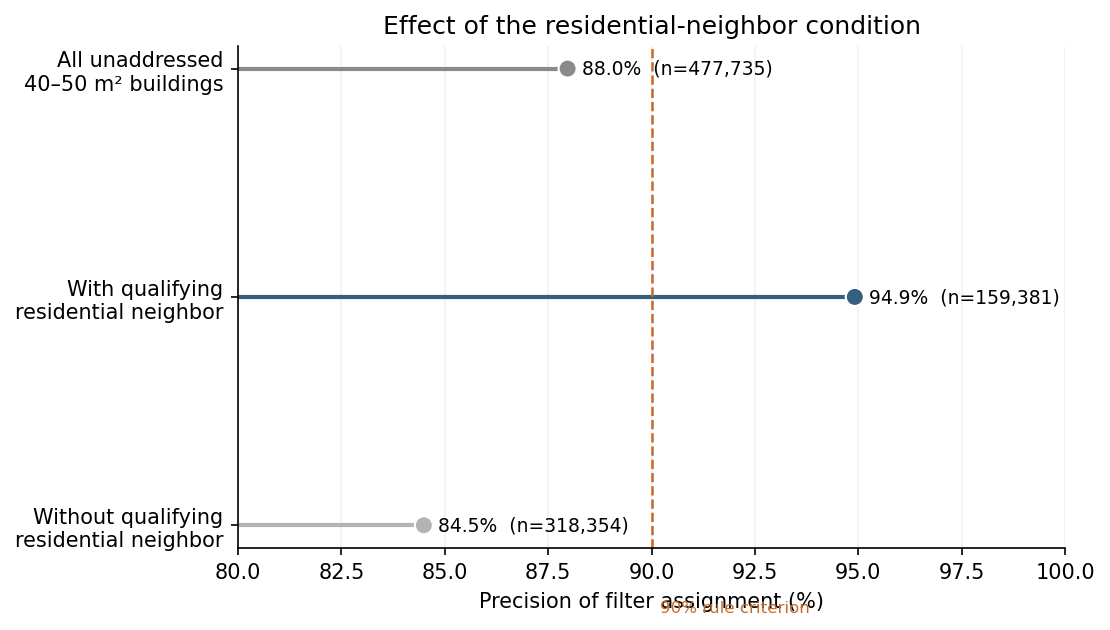

In [45]:
comparison = pd.DataFrame({
    'Group': [
        'All unaddressed\n40–50 m² buildings',
        'With qualifying\nresidential neighbor',
        'Without qualifying\nresidential neighbor'
    ],
    'Precision': [
        (tagged_band['stage1_l1'] == 'filter').mean() * 100,
        (with_neighbour['stage1_l1'] == 'filter').mean() * 100,
        (without_neighbour['stage1_l1'] == 'filter').mean() * 100
    ],
    'Count': [len(tagged_band), len(with_neighbour), len(without_neighbour)]
})

fig, ax = plt.subplots(figsize=(7.5, 4.3))
y = np.arange(len(comparison))
colors = ['#8A8A8A', '#365F7D', '#B3B3B3']

ax.hlines(y, 80, comparison['Precision'], color=colors, linewidth=2)
ax.scatter(comparison['Precision'], y, s=75, color=colors, edgecolor='white', zorder=5)

for i, row in comparison.iterrows():
    ax.text(
        row['Precision'] + 0.35,
        i,
        f"{row['Precision']:.1f}%  (n={row['Count']:,})",
        va='center',
        fontsize=9
    )

ax.axvline(90, color='#C46A2D', linestyle='--', linewidth=1.2)
ax.text(90.2, 2.38, '90% rule criterion', color='#C46A2D', fontsize=8)

ax.set_xlim(80, 100)
ax.set_yticks(y)
ax.set_yticklabels(comparison['Group'])
ax.invert_yaxis()
ax.set_xlabel('Precision of filter assignment (%)')
ax.set_title('Effect of the residential-neighbor condition')
ax.grid(axis='x', alpha=0.18)

plt.tight_layout()
plt.show()

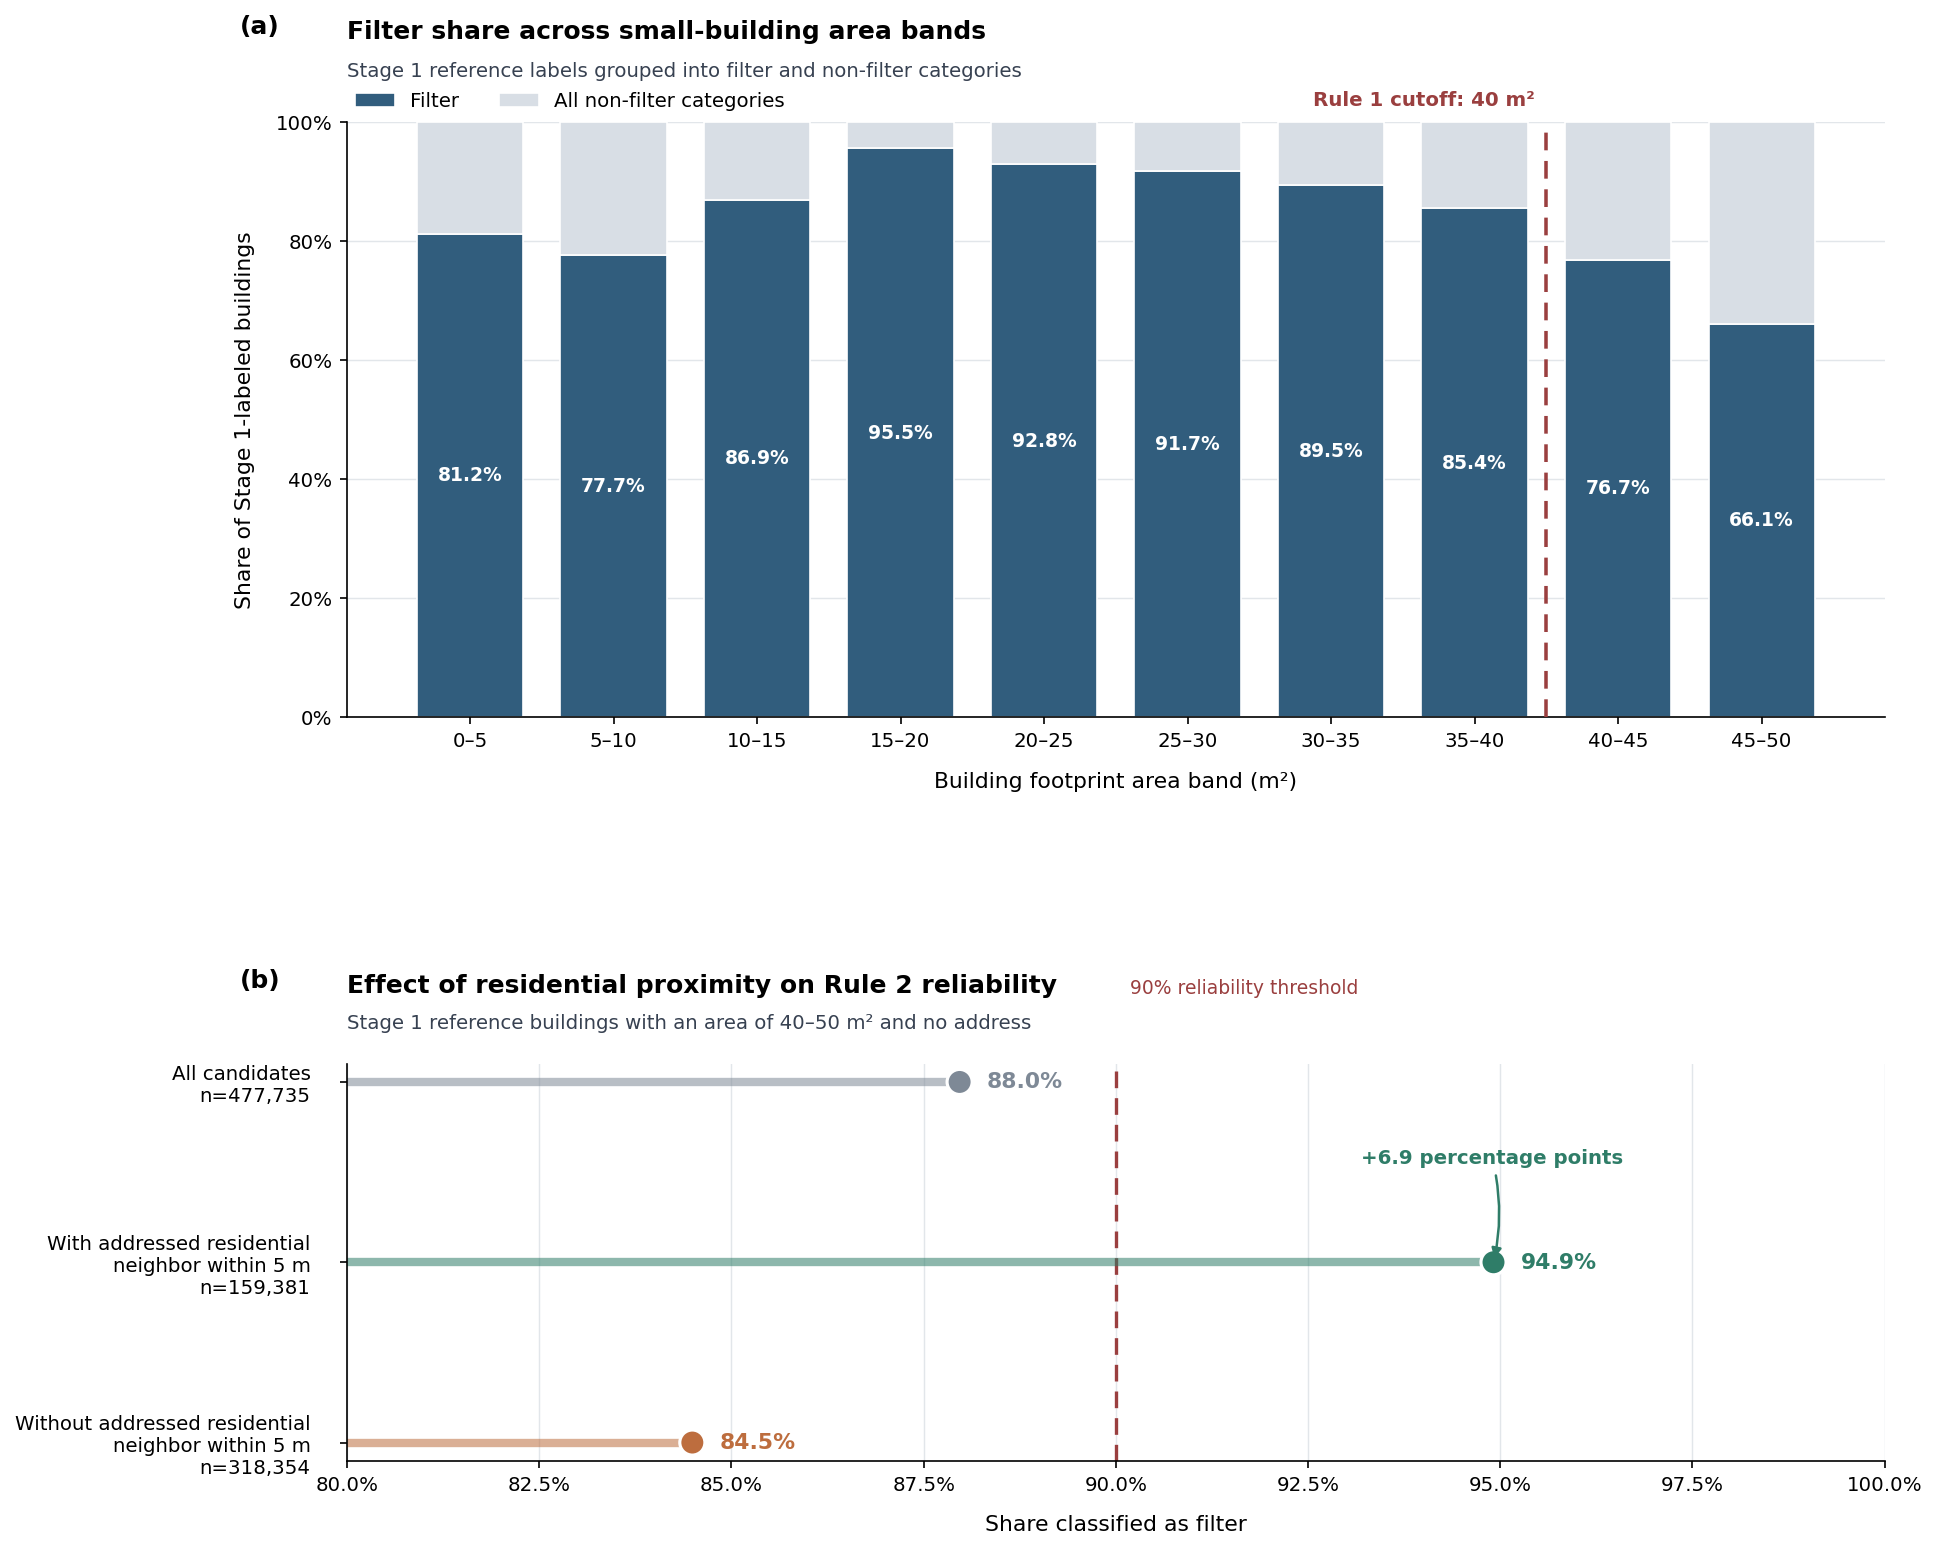

Saved PDF: /fast/home/o-olajuyigbe/figures/stage2_filter_rule_analysis.pdf
Saved PNG: /fast/home/o-olajuyigbe/figures/stage2_filter_rule_analysis.png


In [ ]:
# 
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10.5,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'legend.fontsize': 9.5,
    'axes.spines.top': False,
    'axes.spines.right': False
})

from textwrap import fill

filter_color = '#315D7D'
non_filter_color = '#D8DEE5'
threshold_color = '#9A3F3F'
selected_color = '#2F7D68'
rejected_color = '#BD6D3E'
neutral_color = '#7E8996'
text_color = '#374151'
grid_color = '#D7DCE2'

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12.5, 10.5),
    gridspec_kw={'height_ratios': [1.35, 0.9]}
)

fig.subplots_adjust(left=0.15, right=0.97, top=0.93, bottom=0.08, hspace=0.70)

# PANEL A: RULE 1 AREA THRESHOLD
x1 = np.arange(len(area_summary))

ax1.bar(
    x1, area_summary['filter_share'], width=0.74,
    color=filter_color, edgecolor='white', linewidth=0.8, label='Filter'
)

ax1.bar(
    x1, area_summary['non_filter_share'],
    bottom=area_summary['filter_share'],
    width=0.74, color=non_filter_color,
    edgecolor='white', linewidth=0.8, label='All non-filter categories'
)

for i, row in area_summary.iterrows():
    ax1.text(
        i, row['filter_share'] / 2, f"{row['filter_share']:.1f}%",
        ha='center', va='center', color='white', fontsize=9, fontweight='bold'
    )

cutoff_position = 7.5
ax1.axvline(cutoff_position, color=threshold_color, linewidth=1.7, linestyle=(0, (5, 3)), zorder=4)

ax1.text(
    cutoff_position - 0.08, 1.02, 'Rule 1 cutoff: 40 m²',
    transform=ax1.get_xaxis_transform(),
    ha='right', va='bottom', color=threshold_color, fontsize=9.5, fontweight='bold'
)

ax1.set_title('Filter share across small-building area bands', loc='left', y=1.14, pad=0)

ax1.text(
    0, 1.07,
    'Stage 1 reference labels grouped into filter and non-filter categories',
    transform=ax1.transAxes,
    ha='left', va='bottom', fontsize=9.5, color=text_color
)

ax1.set_xlabel('Building footprint area band (m²)', labelpad=10)
ax1.set_ylabel('Share of Stage 1-labeled buildings', labelpad=10)

ax1.set_xticks(x1)
ax1.set_xticklabels(area_summary['area_band'])

ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(PercentFormatter(100))
ax1.grid(axis='y', color=grid_color, linewidth=0.7, alpha=0.7)
ax1.set_axisbelow(True)

# move legend above plotting area so it does not touch bars
ax1.legend(
    loc='lower left',
    bbox_to_anchor=(0, 1.005),
    frameon=False,
    ncol=2,
    borderaxespad=0
)

ax1.text(-0.07, 1.14, '(a)', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='bottom')

# PANEL B: RULE 2 RESIDENTIAL PROXIMITY
raw_labels = [
    f"All candidates\nn={rule2_summary.loc[0, 'sample_size']:,}",
    f"With addressed residential neighbor within 5 m\nn={rule2_summary.loc[1, 'sample_size']:,}",
    f"Without addressed residential neighbor within 5 m\nn={rule2_summary.loc[2, 'sample_size']:,}"
]

# wrap only the first line, keep n= on a separate line
condition_labels = []
for label in raw_labels:
    main, nline = label.split('\n')
    condition_labels.append(f"{fill(main, width=32)}\n{nline}")

values = rule2_summary['filter_share'].to_numpy()
y2 = np.arange(len(values))
point_colors = [neutral_color, selected_color, rejected_color]

for y, value, color in zip(y2, values, point_colors):
    ax2.hlines(y=y, xmin=80, xmax=value, color=color, linewidth=4, alpha=0.55, zorder=2)

ax2.scatter(values, y2, s=145, color=point_colors, edgecolor='white', linewidth=1.5, zorder=3)

ax2.axvline(90, color=threshold_color, linewidth=1.6, linestyle=(0, (5, 3)), zorder=1)

ax2.text(
    90.18, -0.52, '90% reliability threshold',
    ha='left', va='center', fontsize=9, color=threshold_color
)

for y, value, color in zip(y2, values, point_colors):
    ax2.text(
        value + 0.35, y, f'{value:.1f}%',
        ha='left', va='center', fontsize=10.5, fontweight='bold', color=color
    )

gain = values[1] - values[0]
ax2.annotate(
    f'+{gain:.1f} percentage points',
    xy=(values[1], 1),
    xytext=(96.6, 0.42),
    ha='right', va='center', fontsize=9.5, fontweight='bold', color=selected_color,
    arrowprops={'arrowstyle': '-|>', 'color': selected_color, 'linewidth': 1.2, 'connectionstyle': 'arc3,rad=-0.12'}
)

ax2.set_title('Effect of residential proximity on Rule 2 reliability', loc='left', y=1.18, pad=0)

ax2.text(
    0, 1.08,
    'Stage 1 reference buildings with an area of 40–50 m² and no address',
    transform=ax2.transAxes,
    ha='left', va='bottom', fontsize=9.5, color=text_color
)

ax2.set_xlabel('Share classified as filter', labelpad=10)
ax2.set_yticks(y2)
ax2.set_yticklabels(condition_labels)
ax2.invert_yaxis()

ax2.set_xlim(80, 100)
ax2.xaxis.set_major_formatter(PercentFormatter(100))
ax2.grid(axis='x', color=grid_color, linewidth=0.7, alpha=0.7)
ax2.set_axisbelow(True)

# add more padding so long labels do not crowd plot area
ax2.tick_params(axis='y', pad=14)

ax2.text(-0.07, 1.18, '(b)', transform=ax2.transAxes, fontsize=12, fontweight='bold', va='bottom')


Text(-0.075, 1.18, '(b)')

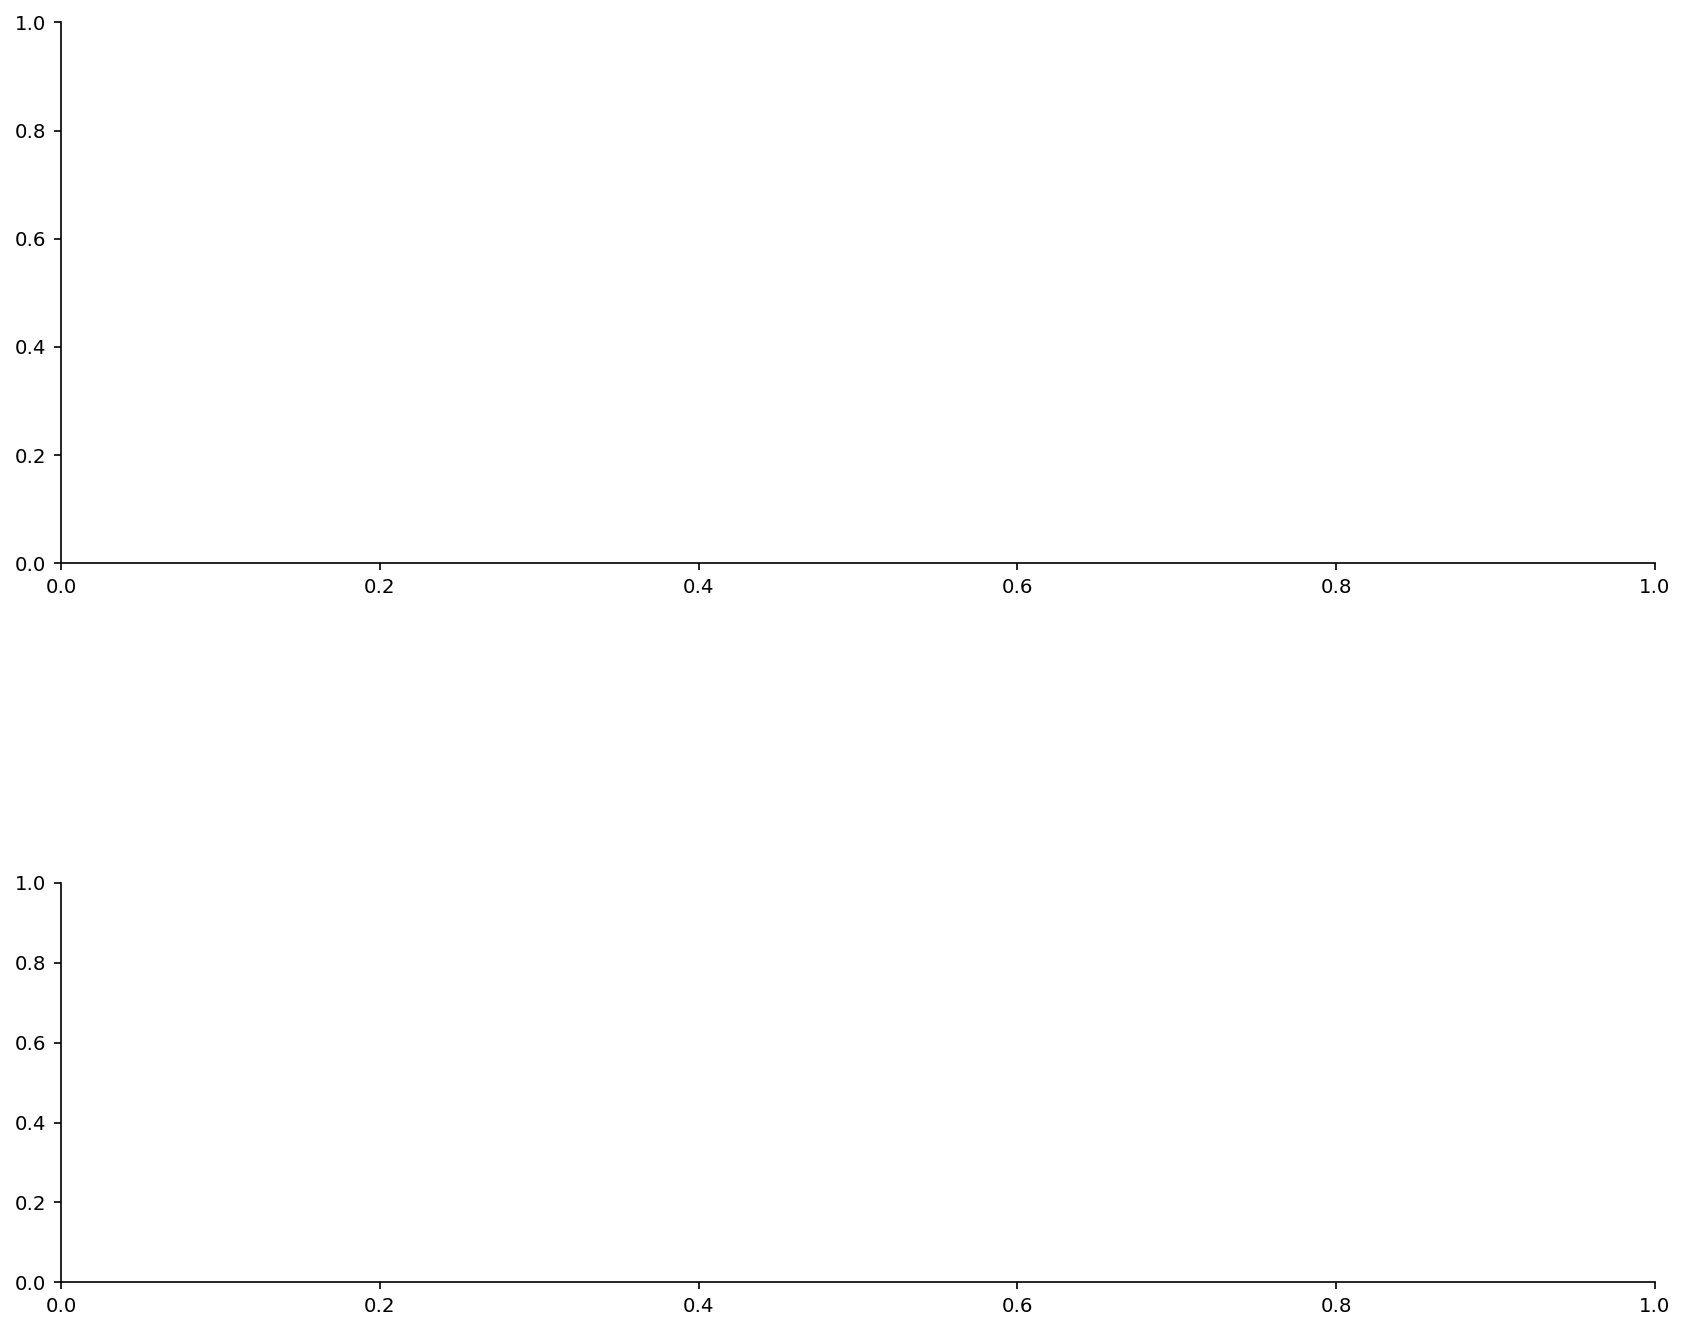

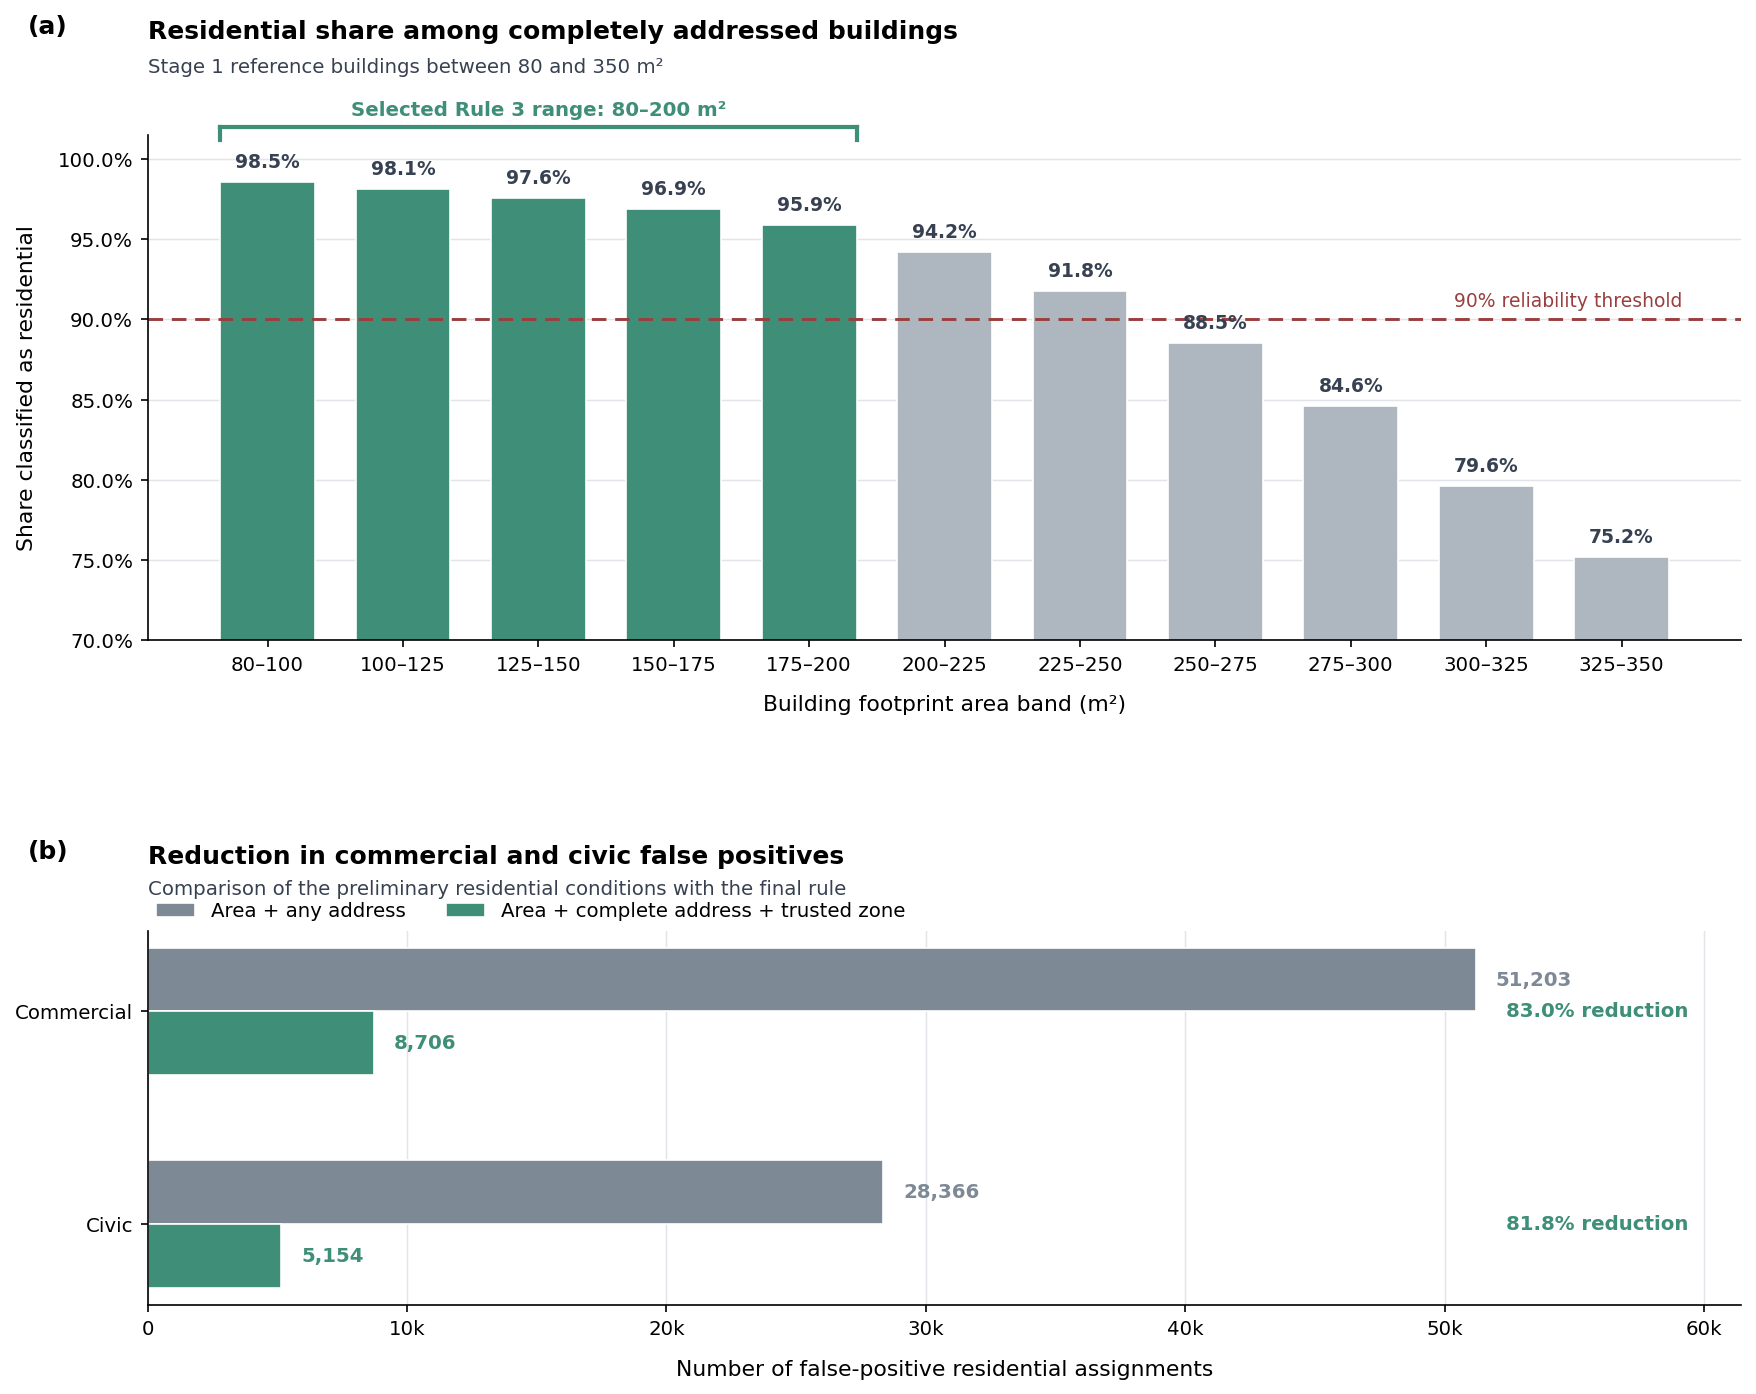

In [ ]:
from pathlib import Path
from matplotlib.ticker import PercentFormatter, FuncFormatter
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
import os

# PREPARE LAND-USE CONTEXT
MAPPED_LANDUSE_FILE = os.path.join(
    DATA_DIR, 'processed', 'germany_landuse_mapped.parquet'
)

plot_bldg = gdf_bldg.copy()

required_building_columns = {
    'id', 'geometry', 'area_sqm', 'address_tier', 'stage1_l1'
}
missing = required_building_columns.difference(plot_bldg.columns)

if missing:
    raise KeyError(f'Missing building columns: {sorted(missing)}')

# Attach mapped land-use polygons if this has not already been done
if not {'landuse_l1', 'landuse_osm_id'}.issubset(plot_bldg.columns):
    print('Attaching mapped land-use polygons...')

    gdf_landuse_mapped = gpd.read_parquet(MAPPED_LANDUSE_FILE)

    required_landuse_columns = {
        'id', 'geometry', 'zone_l1', 'zone_l2', 'landuse'
    }
    missing = required_landuse_columns.difference(gdf_landuse_mapped.columns)

    if missing:
        raise KeyError(f'Missing mapped land-use columns: {sorted(missing)}')

    if gdf_landuse_mapped.crs != plot_bldg.crs:
        gdf_landuse_mapped = gdf_landuse_mapped.to_crs(plot_bldg.crs)

    if 'zone_area_sqm' not in gdf_landuse_mapped.columns:
        gdf_landuse_mapped['zone_area_sqm'] = (
            gdf_landuse_mapped.to_crs(epsg=3035).geometry.area.values
        )

    # Compute building centroids in a projected CRS
    centroids = plot_bldg[['id', 'geometry']].copy()
    centroids_metric = centroids.to_crs(epsg=3035)
    centroids['geometry'] = (
        centroids_metric.geometry.centroid.to_crs(plot_bldg.crs)
    )

    joined = gpd.sjoin(
        centroids,
        gdf_landuse_mapped[
            ['id', 'geometry', 'zone_l1', 'zone_l2',
             'landuse', 'zone_area_sqm']
        ],
        how='left',
        predicate='within',
        lsuffix='bldg',
        rsuffix='zone'
    )

    # Smaller polygons are preferred; priority resolves remaining ties
    priority = {
        'industrial': 1,
        'retail': 2,
        'military': 2,
        'commercial': 3,
        'residential': 4
    }

    joined['_priority'] = joined['landuse'].map(priority).fillna(9)

    joined = joined.sort_values(
        ['id_bldg', 'zone_area_sqm', '_priority'],
        ascending=[True, True, True]
    )

    # Identify buildings contained in both residential and commercial zones
    residential_ids = set(
        joined.loc[joined['zone_l1'].eq('residential'), 'id_bldg']
    )
    commercial_ids = set(
        joined.loc[joined['zone_l1'].eq('commercial'), 'id_bldg']
    )
    semi_commercial_ids = residential_ids & commercial_ids

    joined_clean = (
        joined
        .drop_duplicates(subset='id_bldg', keep='first')
        .set_index('id_bldg')
    )

    plot_bldg['landuse_l1'] = plot_bldg['id'].map(
        joined_clean['zone_l1']
    )
    plot_bldg['landuse_l2'] = plot_bldg['id'].map(
        joined_clean['zone_l2']
    )
    plot_bldg['landuse_used'] = plot_bldg['id'].map(
        joined_clean['landuse']
    )
    plot_bldg['landuse_osm_id'] = plot_bldg['id'].map(
        joined_clean['id_zone']
    )

    plot_bldg.loc[
        plot_bldg['id'].isin(semi_commercial_ids),
        'landuse_l1'
    ] = 'semi_commercial'

    plot_bldg.loc[
        plot_bldg['id'].isin(semi_commercial_ids),
        'landuse_used'
    ] = 'residential_commercial'

# IDENTIFY TRUSTED RESIDENTIAL POLYGONS
residential_zone_reference = plot_bldg[
    plot_bldg['stage1_l1'].notna()
    & plot_bldg['stage1_l1'].ne('filter')
    & plot_bldg['landuse_l1'].eq('residential')
    & plot_bldg['landuse_osm_id'].notna()
].copy()

residential_zone_summary = (
    residential_zone_reference
    .groupby('landuse_osm_id')['stage1_l1']
    .agg(
        n_labeled='size',
        n_residential=lambda values: values.eq('residential').sum()
    )
    .reset_index()
)

residential_zone_summary['agreement_rate'] = (
    residential_zone_summary['n_residential']
    / residential_zone_summary['n_labeled']
)

# Final residential requirement: at least 5 labeled buildings and 90% agreement
trusted_residential = set(
    residential_zone_summary.loc[
        residential_zone_summary['n_labeled'].ge(5)
        & residential_zone_summary['agreement_rate'].ge(0.90),
        'landuse_osm_id'
    ]
)

print(f'Trusted residential polygons: {len(trusted_residential):,}')

# PANEL A: RESIDENTIAL SHARE BY AREA BAND

residential_bins = [
    80, 100, 125, 150, 175, 200,
    225, 250, 275, 300, 325, 350
]

residential_labels = [
    '80–100', '100–125', '125–150', '150–175', '175–200',
    '200–225', '225–250', '250–275', '275–300', '300–325',
    '325–350'
]

# Use complete addresses because this is the final Rule 3 condition
addressed_reference = plot_bldg[
    plot_bldg['stage1_l1'].notna()
    & plot_bldg['address_tier'].eq(2)
    & plot_bldg['area_sqm'].between(80, 350)
][['area_sqm', 'stage1_l1']].copy()

addressed_reference['area_band'] = pd.cut(
    addressed_reference['area_sqm'],
    bins=residential_bins,
    labels=residential_labels,
    include_lowest=True
)

residential_area_summary = (
    addressed_reference
    .groupby('area_band', observed=False)['stage1_l1']
    .agg(
        n_labeled='size',
        n_residential=lambda values: values.eq('residential').sum()
    )
    .reset_index()
)

residential_area_summary['residential_share'] = (
    residential_area_summary['n_residential']
    / residential_area_summary['n_labeled']
    * 100
)

# PANEL B: COMMERCIAL AND CIVIC FALSE POSITIVES
tagged = plot_bldg[plot_bldg['stage1_l1'].notna()].copy()

# Preliminary rule: typical residential area and any address information
preliminary_mask = (
    tagged['area_sqm'].between(80, 200)
    & tagged['address_tier'].ge(1)
)

# Final rule: typical area, complete address and trusted residential zone
final_mask = (
    tagged['area_sqm'].between(80, 200)
    & tagged['address_tier'].eq(2)
    & tagged['landuse_osm_id'].isin(trusted_residential)
)

preliminary_candidates = tagged[preliminary_mask]
final_candidates = tagged[final_mask]

false_positive_classes = ['commercial', 'civic']

preliminary_fp = (
    preliminary_candidates['stage1_l1']
    .value_counts()
    .reindex(false_positive_classes, fill_value=0)
)

final_fp = (
    final_candidates['stage1_l1']
    .value_counts()
    .reindex(false_positive_classes, fill_value=0)
)

false_positive_summary = pd.DataFrame({
    'category': ['Commercial', 'Civic'],
    'Preliminary rule': preliminary_fp.values,
    'Final rule': final_fp.values
})

false_positive_summary['reduction'] = (
    1
    - false_positive_summary['Final rule']
    / false_positive_summary['Preliminary rule']
) * 100

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10.5,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'legend.fontsize': 9.5,
    'axes.spines.top': False,
    'axes.spines.right': False
})

selected_color = '#3E8E78'
outside_color = '#AEB6C0'
preliminary_color = '#7E8996'
final_color = '#3E8E78'
threshold_color = '#9A3F3F'
text_color = '#374151'
grid_color = '#D7DCE2'

def compact_number(value, _=None):
    if value >= 1_000_000:
        return f'{value / 1_000_000:.1f}M'
    if value >= 1_000:
        return f'{value / 1_000:.0f}k'
    return f'{value:,.0f}'

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12.5, 10),
    gridspec_kw={'height_ratios': [1.15, 0.85]}
)

fig.subplots_adjust(
    left=0.12,
    right=0.97,
    top=0.93,
    bottom=0.09,
    hspace=0.68
)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12.5, 10),
    gridspec_kw={'height_ratios': [1.15, 0.85]}
)

fig.subplots_adjust(
    left=0.12,
    right=0.97,
    top=0.87,       
    bottom=0.09,
    hspace=0.66
)

# PANEL A: RESIDENTIAL AREA RANGE
x = np.arange(len(residential_area_summary))
selected_range = x <= 4

bar_colors = np.where(
    selected_range,
    selected_color,
    outside_color
)

bars = ax1.bar(
    x,
    residential_area_summary['residential_share'],
    width=0.70,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

# Reliability threshold
ax1.axhline(
    90,
    color=threshold_color,
    linewidth=1.4,
    linestyle=(0, (5, 3))
)

ax1.text(
    len(x) - 0.55,
    90.55,
    '90% reliability threshold',
    ha='right',
    va='bottom',
    fontsize=9,
    color=threshold_color
)

# Percentage labels
for bar, row in zip(bars, residential_area_summary.itertuples()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        row.residential_share + 0.65,
        f'{row.residential_share:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=text_color
    )

# Bracket marking the selected 80–200 m² range
bracket_y = 1.015
bracket_left = -0.35
bracket_right = 4.35

ax1.plot(
    [bracket_left, bracket_right],
    [bracket_y, bracket_y],
    transform=ax1.get_xaxis_transform(),
    color=selected_color,
    linewidth=2,
    clip_on=False
)

ax1.plot(
    [bracket_left, bracket_left],
    [bracket_y - 0.025, bracket_y],
    transform=ax1.get_xaxis_transform(),
    color=selected_color,
    linewidth=2,
    clip_on=False
)

ax1.plot(
    [bracket_right, bracket_right],
    [bracket_y - 0.025, bracket_y],
    transform=ax1.get_xaxis_transform(),
    color=selected_color,
    linewidth=2,
    clip_on=False
)

ax1.text(
    (bracket_left + bracket_right) / 2,
    bracket_y + 0.014,
    'Selected Rule 3 range: 80–200 m²',
    transform=ax1.get_xaxis_transform(),
    ha='center',
    va='bottom',
    fontsize=9.5,
    fontweight='bold',
    color=selected_color,
    clip_on=False
)

# Title and subtitle
ax1.set_title(
    'Residential share among completely addressed buildings',
    loc='left',
    y=1.19,
    pad=0
)

ax1.text(
    0,
    1.115,
    'Stage 1 reference buildings between 80 and 350 m²',
    transform=ax1.transAxes,
    ha='left',
    va='bottom',
    fontsize=9.5,
    color=text_color
)

# Panel label
ax1.text(
    -0.075,
    1.19,
    '(a)',
    transform=ax1.transAxes,
    fontsize=12,
    fontweight='bold',
    va='bottom'
)

# Axes
ax1.set_xlabel('Building footprint area band (m²)', labelpad=10)
ax1.set_ylabel('Share classified as residential', labelpad=10)

ax1.set_xticks(x)
ax1.set_xticklabels(residential_area_summary['area_band'])

# Extra upper space for labels without extending to an unnecessary 105%
ax1.set_ylim(70, 101.5)
ax1.yaxis.set_major_formatter(PercentFormatter(100))

ax1.grid(
    axis='y',
    color=grid_color,
    linewidth=0.7,
    alpha=0.75
)

ax1.set_axisbelow(True)

# PANEL B

y = np.arange(len(false_positive_summary))
bar_height = 0.30

before_bars = ax2.barh(
    y - bar_height / 2,
    false_positive_summary['Preliminary rule'],
    height=bar_height,
    color=preliminary_color,
    edgecolor='white',
    linewidth=0.8,
    label='Area + any address'
)

after_bars = ax2.barh(
    y + bar_height / 2,
    false_positive_summary['Final rule'],
    height=bar_height,
    color=final_color,
    edgecolor='white',
    linewidth=0.8,
    label='Area + complete address + trusted zone'
)

maximum_count = false_positive_summary['Preliminary rule'].max()

for bar in before_bars:
    value = int(bar.get_width())
    ax2.text(
        value + maximum_count * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        ha='left',
        va='center',
        fontsize=9.5,
        fontweight='bold',
        color=preliminary_color
    )

for bar in after_bars:
    value = int(bar.get_width())
    ax2.text(
        value + maximum_count * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        ha='left',
        va='center',
        fontsize=9.5,
        fontweight='bold',
        color=final_color
    )

for i, row in false_positive_summary.iterrows():
    ax2.text(
        maximum_count * 1.16,
        i,
        f"{row['reduction']:.1f}% reduction",
        ha='right',
        va='center',
        fontsize=9.5,
        fontweight='bold',
        color=final_color
    )

ax2.set_title(
    'Reduction in commercial and civic false positives',
    loc='left',
    y=1.18,
    pad=0
)

ax2.text(
    0,
    1.085,
    'Comparison of the preliminary residential conditions with the final rule',
    transform=ax2.transAxes,
    ha='left',
    va='bottom',
    fontsize=9.5,
    color=text_color
)

ax2.set_xlabel('Number of false-positive residential assignments', labelpad=10)
ax2.set_yticks(y)
ax2.set_yticklabels(false_positive_summary['category'])
ax2.invert_yaxis()
ax2.set_xlim(0, maximum_count * 1.20)
ax2.xaxis.set_major_formatter(FuncFormatter(compact_number))
ax2.grid(axis='x', color=grid_color, linewidth=0.7, alpha=0.75)
ax2.set_axisbelow(True)

ax2.legend(
    loc='lower left',
    bbox_to_anchor=(0, 1.005),
    frameon=False,
    ncol=2,
    borderaxespad=0
)

ax2.text(
    -0.075,
    1.18,
    '(b)',
    transform=ax2.transAxes,
    fontsize=12,
    fontweight='bold',
    va='bottom'
)